In [13]:
from google.colab import drive
drive.mount('/content/drive')
# The folder 'Intelligent-Cloud-Resource-Optimization-System'
# will then be accessible at:
# '/content/drive/MyDrive/Intelligent-Cloud-Resource-Optimization-System'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os

# Change the current working directory to the specified folder
project_root = '/content/drive/MyDrive/Intelligent-Cloud-Resource-Optimization-System'
os.chdir(project_root)

print(f"Current working directory changed to: {os.getcwd()}")

Current working directory changed to: /content/drive/MyDrive/Intelligent-Cloud-Resource-Optimization-System


<div style='background:linear-gradient(135deg,#2C3E50,#3498DB);
            padding:40px;border-radius:12px;text-align:center'>
  <h1 style='color:white;font-size:2.4em;margin:0'>
    ☁️ Cloud Resource Optimisation
  </h1>
  <h2 style='color:#AED6F1;margin:8px 0 0'>
    Machine Learning Capstone Project
  </h2>
  <p style='color:#D6EAF8;margin-top:14px;font-size:1.05em'>
    Stages 1–5 &nbsp;|&nbsp; Supervised · Unsupervised · Learning Theory · RL · Dashboard
  </p>
</div>


## 📚 Table of Contents

| # | Stage | Description |
|---|-------|-------------|
| 0 | **Setup** | Install dependencies, imports, global config |
| 1 | **Exploratory Data Analysis** | Load dataset, statistics, distributions, correlations |
| 2 | **Supervised Learning** | Regression + Classification pipelines |
| 3 | **Unsupervised Learning** | Clustering — KMeans, DBSCAN, Agglomerative |
| 4 | **Learning Theory** | Bias-Variance, regularisation, VC dimension |
| 5 | **Reinforcement Learning** | Q-Learning, DQN, cloud scheduling MDP |
| 6 | **Final Dashboard** | Cross-stage leaderboard, master report |

> 💡 **Tip:** Run cells **top-to-bottom**. Each stage depends on the one above.
> Use `Kernel → Restart & Run All` for a clean full run.


---
# 🔧 Stage 0 — Environment Setup
> Install all required packages and configure global settings.


In [15]:
# ── Install dependencies (run once) ──────────────────────────────────────────
# If running locally, uncomment the line below.
# If running on Google Colab, this cell runs automatically.

# !pip install -r requirements.txt --quiet
print('✅ Dependencies ready.')

✅ Dependencies ready.


In [16]:
# ── Core imports ─────────────────────────────────────────────────────────────
import os, sys, warnings, json, random
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Project modules ───────────────────────────────────────────────────────────
sys.path.insert(0, str(Path('.').resolve()))
from evaluation.metrics_report   import (
    RegressionMetricsReport,
    ClassificationMetricsReport,
    ClusteringMetricsReport,
    RLMetricsReport,
    generate_master_report,
)
from evaluation.model_comparison import (
    RegressionComparator,
    ClassificationComparator,
    CrossStageLeaderboard,
)

# ── Global config ─────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
SEED      = 42
np.random.seed(SEED)
random.seed(SEED)

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
})

DATA_PATH    = 'data/cloud_perfomance.csv'
REPORTS_DIR  = 'reports'
os.makedirs(REPORTS_DIR, exist_ok=True)

print('✅ All imports successful.')
print(f'   NumPy   {np.__version__}')
print(f'   Pandas  {pd.__version__}')

✅ All imports successful.
   NumPy   2.0.2
   Pandas  2.2.2


---
# 📊 Stage 1 — Exploratory Data Analysis (EDA)

**Objectives**
- Understand the dataset shape, feature types, and distributions.
- Detect missing values and outliers.
- Compute a correlation matrix and identify predictive features.

**Dataset:** `cloud_performance.csv` — 10 000 rows of cloud VM telemetry.  
**Key columns:** `cpu_usage`, `memory_usage`, `network_traffic`,
`power_consumption`, `execution_time`, `energy_efficiency`,
`resource_utilisation`, `workload_class`.


In [17]:
# ── 1.1 Load dataset ──────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f'Shape  : {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape  : (1048575, 12)
Columns: ['vm_id', 'timestamp', 'cpu_usage', 'memory_usage', 'network_traffic', 'power_consumption', 'num_executed_instructions', 'execution_time', 'energy_efficiency', 'task_type', 'task_priority', 'task_status']


,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status
0,c5215826-6237-4a33-9312-72c1df909881,1/25/2023 9:10,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,1/26/2023 4:46,71.518937,29.901883,NaN,362.273569,5348.0,41.396040,0.349856,io,high,completed
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,1/13/2023 23:39,NaN,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed
3,e672e32f-c134-4fbc-992b-34eb63bef6bf,2/9/2023 11:45,54.488318,88.100960,NaN,195.639954,5876.0,16.456670,0.529511,compute,high,completed
4,f38b8b50-6926-4533-be4f-89ad11624071,6/14/2023 8:27,42.365480,NaN,NaN,359.451537,3361.0,55.307992,0.351907,NaN,medium,waiting


In [18]:
# ── 1.2 Descriptive statistics ────────────────────────────────────────────────
display(df.describe(include='all').T)

print('\nMissing values per column:')
print(df.isnull().sum())

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
vm_id,44906,44906,275e2418-1e49-483b-8e29-2d49ea3437b7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,44849,41590,3/28/2023 21:26,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cpu_usage,45045.0,NaN,NaN,NaN,49.853348,28.907498,0.007245,24.702799,49.957065,74.892985,99.997795
memory_usage,45002.0,NaN,NaN,NaN,49.956773,28.954514,0.001615,24.953654,50.017994,75.297076,99.992362
network_traffic,44942.0,NaN,NaN,NaN,500.052563,289.119767,0.006439,250.036199,499.566886,750.573834,999.98702
power_consumption,45055.0,NaN,NaN,NaN,249.617055,144.157178,0.012858,125.027862,249.218379,374.244168,499.97025
num_executed_instructions,45024.0,NaN,NaN,NaN,4981.38113,2887.399178,0.0,2457.0,4979.5,7482.0,9999.0
execution_time,45068.0,NaN,NaN,NaN,49.89103,28.792466,0.002654,25.052289,50.050852,74.746827,99.9983
energy_efficiency,44920.0,NaN,NaN,NaN,0.502679,0.289175,0.0,0.251262,0.504999,0.752913,0.999979
task_type,44868,3,network,15072,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values per column:
vm_id                        1003669
timestamp                    1003726
cpu_usage                    1003530
memory_usage                 1003573
network_traffic              1003633
power_consumption            1003520
num_executed_instructions    1003551
execution_time               1003507
energy_efficiency            1003655
task_type                    1003707
task_priority                1003590
task_status                  1003569
dtype: int64


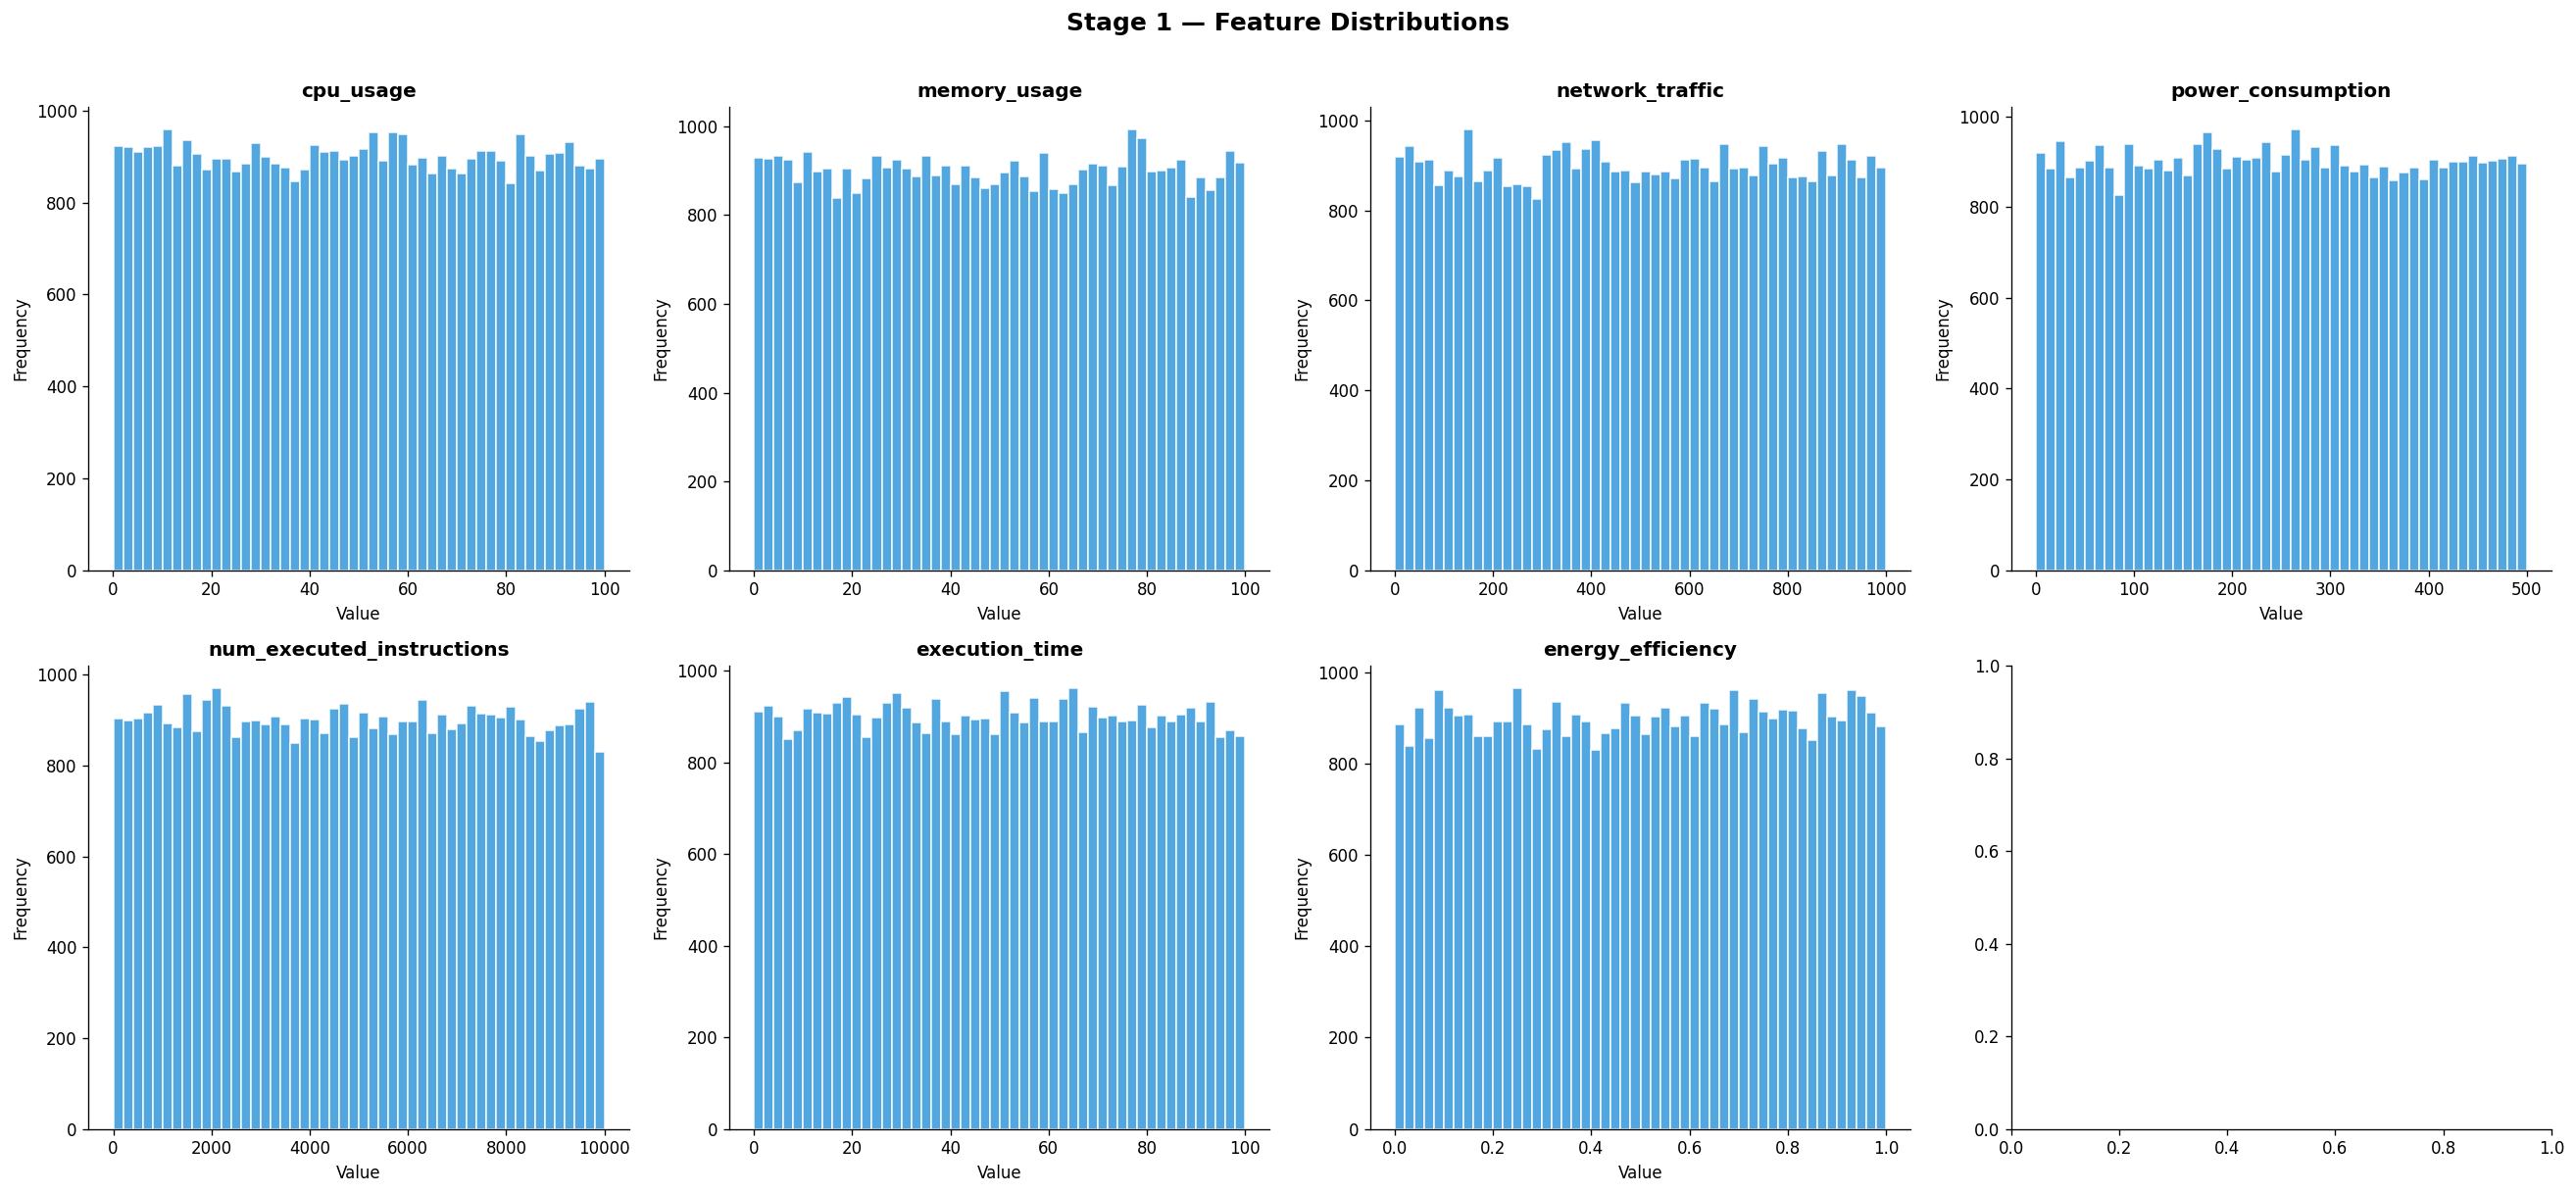

In [19]:
# ── 1.3 Feature distributions ─────────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()

for i, col in enumerate(numeric_cols[:8]):
    axes[i].hist(df[col].dropna(), bins=50,
                  color='#3498DB', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Stage 1 — Feature Distributions',
              fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/stage1_distributions.png',
             dpi=150, bbox_inches='tight')
plt.show()

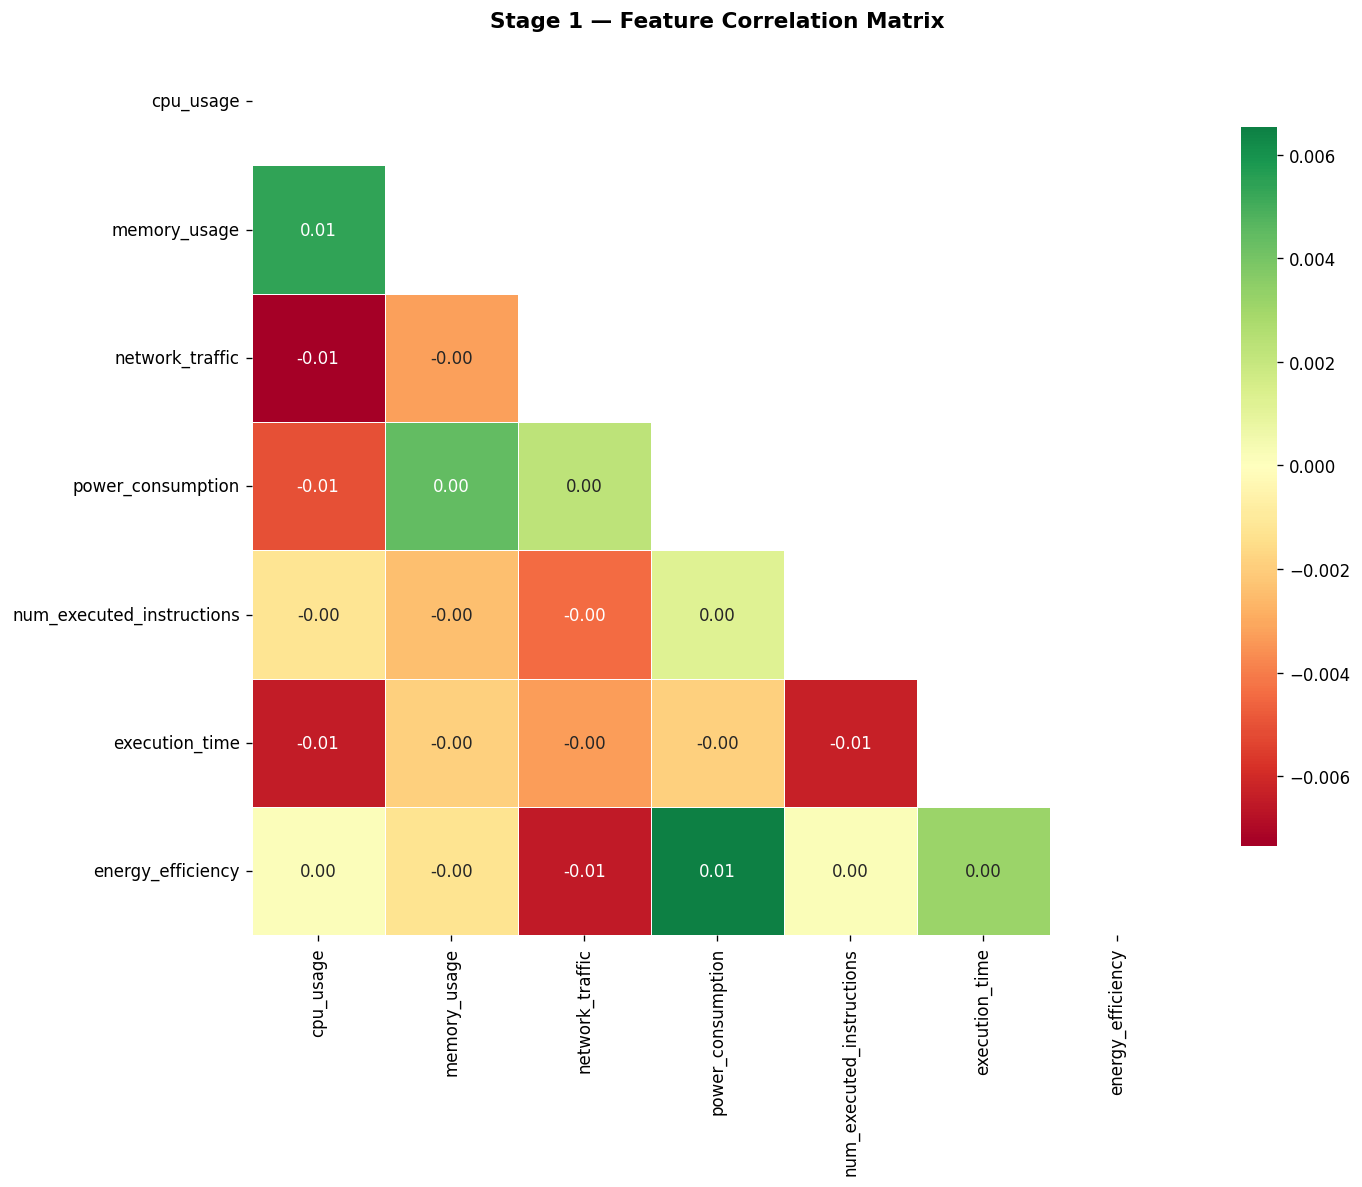

In [20]:
# ── 1.4 Correlation heatmap ───────────────────────────────────────────────────
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
             cmap='RdYlGn', center=0,
             linewidths=0.5, ax=ax,
             cbar_kws={'shrink': 0.8})
ax.set_title('Stage 1 — Feature Correlation Matrix',
              fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/stage1_correlation.png',
             dpi=150, bbox_inches='tight')
plt.show()

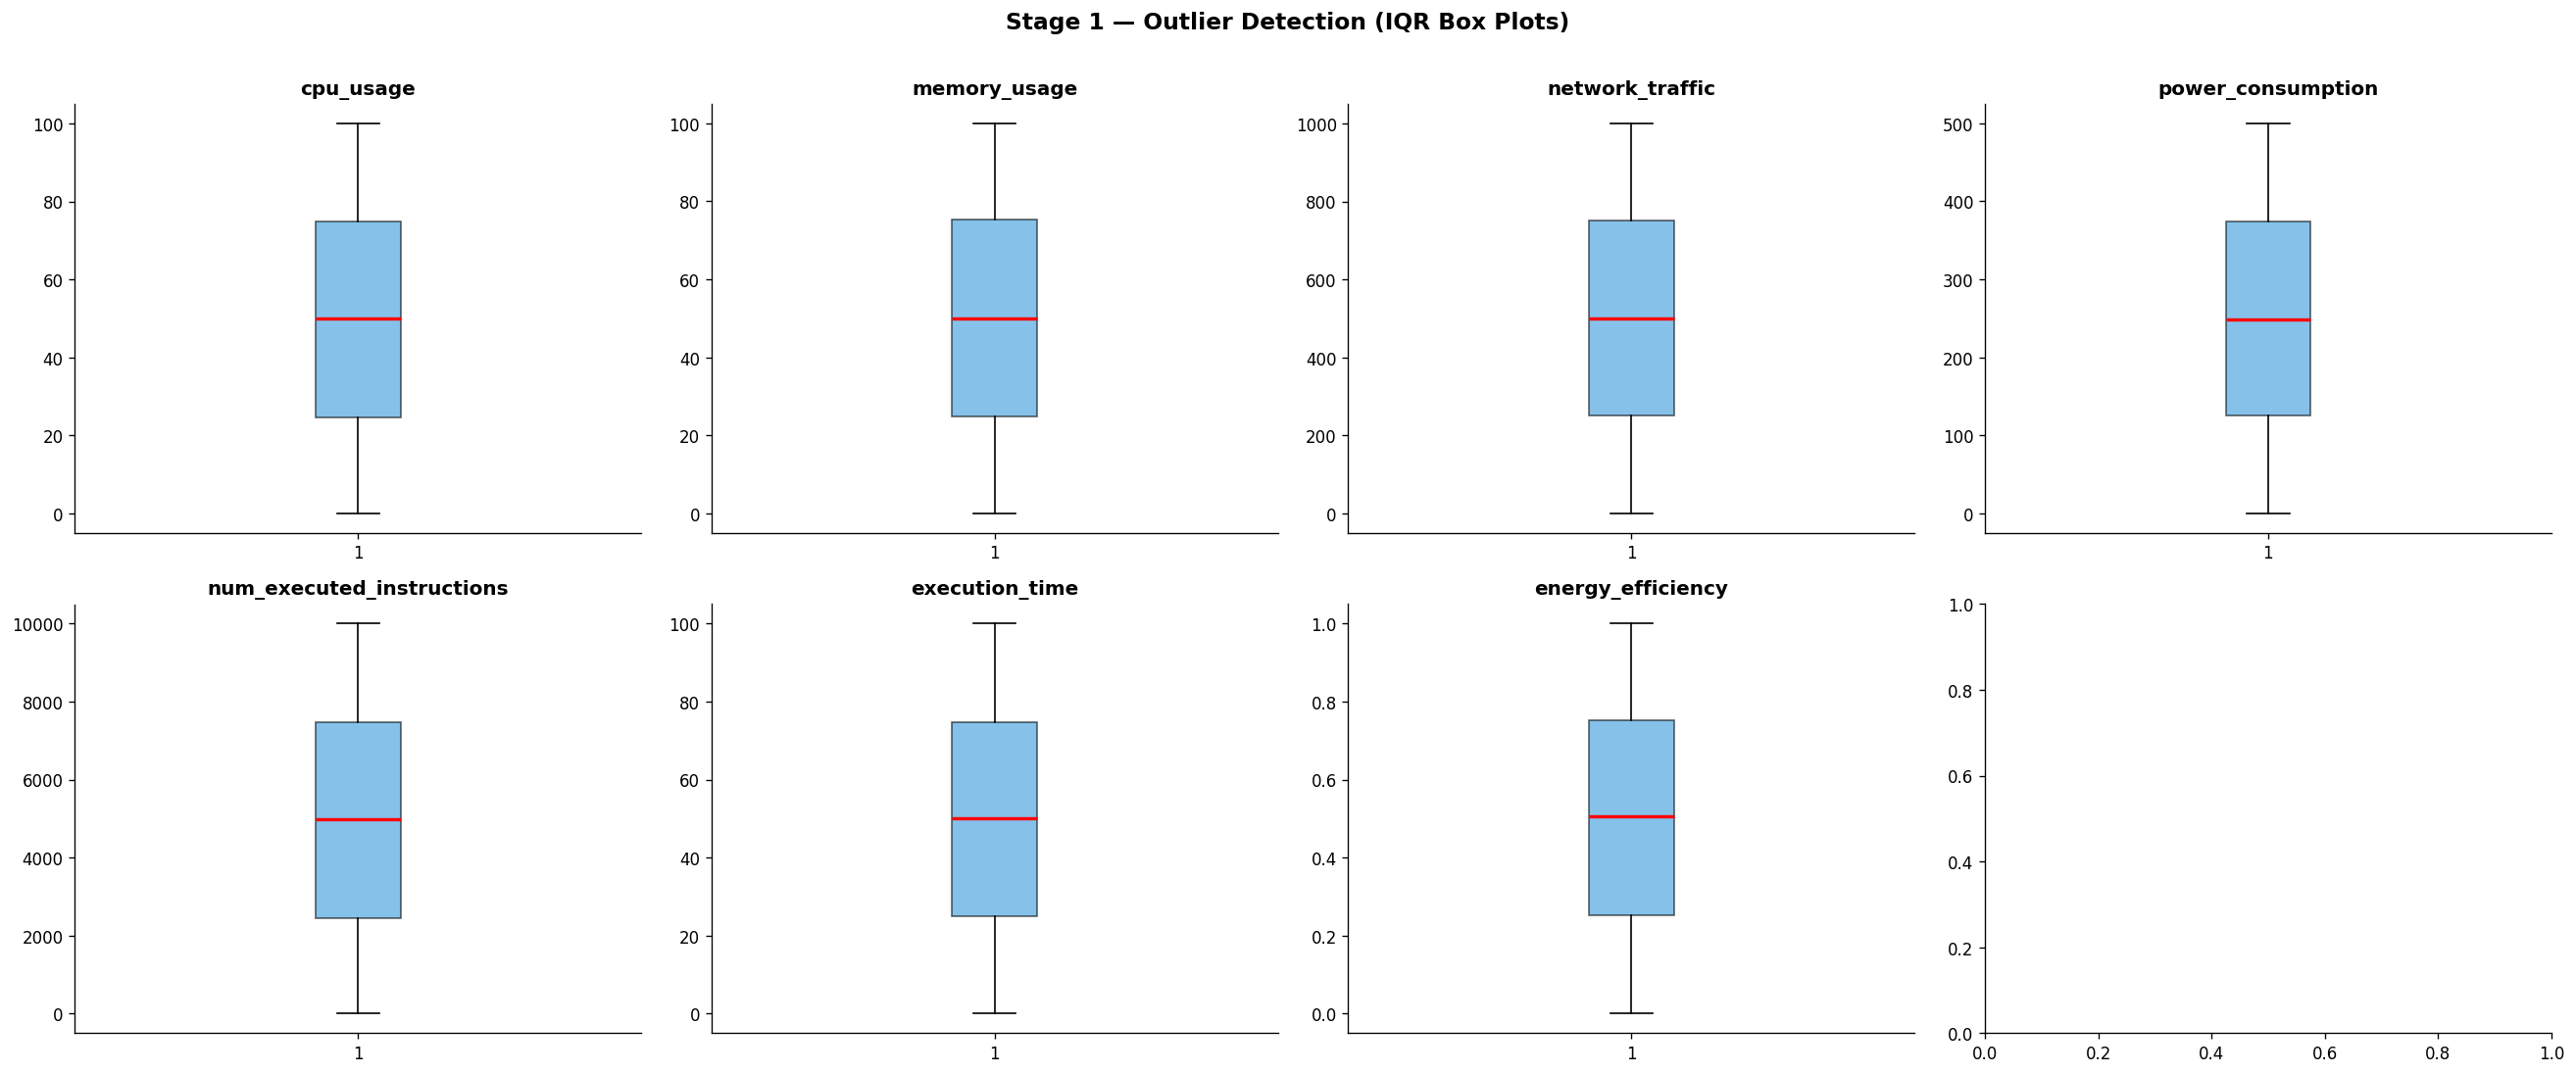

✅ Stage 1 — EDA complete.
{
  "n_rows": 1048575,
  "n_cols": 12,
  "missing_total": 12043230,
  "numeric_cols": [
    "cpu_usage",
    "memory_usage",
    "network_traffic",
    "power_consumption",
    "num_executed_instructions",
    "execution_time",
    "energy_efficiency"
  ]
}


In [21]:
# ── 1.5 Outlier detection — IQR box plots ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.ravel()

for i, col in enumerate(numeric_cols[:8]):
    axes[i].boxplot(df[col].dropna(),
                     patch_artist=True,
                     boxprops=dict(facecolor='#3498DB', alpha=0.6),
                     medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')

plt.suptitle('Stage 1 — Outlier Detection (IQR Box Plots)',
              fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/stage1_outliers.png',
             dpi=150, bbox_inches='tight')
plt.show()

# ── EDA results stored for leaderboard ───────────────────────────────────────
eda_results = {
    'n_rows'        : int(df.shape[0]),
    'n_cols'        : int(df.shape[1]),
    'missing_total' : int(df.isnull().sum().sum()),
    'numeric_cols'  : numeric_cols,
}
print('✅ Stage 1 — EDA complete.')
print(json.dumps(eda_results, indent=2))

---
# 🤖 Stage 2 — Supervised Learning

**Part A — Regression:**  Predict `execution_time` (continuous target).  
**Part B — Classification:**  Predict `workload_class` (Low / Medium / High).

Models compared in each part:

| Part | Models |
|------|--------|
| Regression | Linear Regression · Ridge · Lasso · Random Forest · Gradient Boosting |
| Classification | Logistic Regression · SVM · KNN · Random Forest · GBM |


In [22]:
# ── 2.0 Common imports ────────────────────────────────────────────────────────
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.pipeline         import Pipeline
from sklearn.linear_model     import LinearRegression, Ridge, Lasso
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm              import SVR, SVC
from sklearn.neighbors        import KNeighborsClassifier

print('✅ Supervised learning imports ready.')

✅ Supervised learning imports ready.


In [23]:
# ── 2.A.1 Regression — data preparation ──────────────────────────────────────
REG_FEATURES = ['cpu_usage', 'memory_usage', 'network_traffic',
                 'power_consumption', 'energy_efficiency']
REG_TARGET   = 'execution_time'

df_reg  = df[REG_FEATURES + [REG_TARGET]].dropna()
X_reg   = df_reg[REG_FEATURES].values
y_reg   = df_reg[REG_TARGET].values

X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=SEED)

scaler_reg  = StandardScaler()
X_reg_tr_sc = scaler_reg.fit_transform(X_reg_tr)
X_reg_te_sc = scaler_reg.transform(X_reg_te)

print(f'Regression  — Train: {X_reg_tr.shape}  Test: {X_reg_te.shape}')

Regression  — Train: (21333, 5)  Test: (5334, 5)


In [24]:
# ── 2.A.2 Train regression models ─────────────────────────────────────────────
reg_models = {
    'Linear Regression'    : LinearRegression(),
    'Ridge (α=1)'          : Ridge(alpha=1.0),
    'Lasso (α=0.01)'       : Lasso(alpha=0.01, max_iter=5000),
    'Random Forest'        : RandomForestRegressor(
                                n_estimators=100, random_state=SEED),
    'Gradient Boosting'    : GradientBoostingRegressor(
                                n_estimators=100, random_state=SEED),
}

reg_rpt = RegressionMetricsReport()
reg_cmp = RegressionComparator()

for name, model in reg_models.items():
    model.fit(X_reg_tr_sc, y_reg_tr)
    y_tr_pred = model.predict(X_reg_tr_sc)
    y_te_pred = model.predict(X_reg_te_sc)

    from sklearn.metrics import r2_score as r2
    reg_rpt.add_model(name, y_reg_te, y_te_pred,
                       y_train=y_reg_tr,
                       y_train_pred=y_tr_pred)
    reg_cmp.add(name, y_reg_te, y_te_pred,
                 train_r2=float(r2(y_reg_tr, y_tr_pred)))
    print(f'  Trained: {name}')

print('\n✅ All regression models trained.')

  Trained: Linear Regression
  Trained: Ridge (α=1)
  Trained: Lasso (α=0.01)
  Trained: Random Forest
  Trained: Gradient Boosting

✅ All regression models trained.



════════════════════════════════════════════════════════════════════════
  REGRESSION METRICS SUMMARY
════════════════════════════════════════════════════════════════════════
            Model      R²  Adj R²    RMSE     MAE  MAPE (%)  Expl Var  Overfit Gap
Linear Regression -0.0005 -0.0007 28.9758 25.1387    385.20   -0.0004       0.0006
      Ridge (α=1) -0.0005 -0.0007 28.9758 25.1387    385.20   -0.0004       0.0006
   Lasso (α=0.01) -0.0005 -0.0007 28.9753 25.1384    385.19   -0.0003       0.0006
Gradient Boosting -0.0026 -0.0028 29.0063 25.1369    382.76   -0.0025       0.0292
    Random Forest -0.0291 -0.0293 29.3868 25.3825    389.15   -0.0290       0.8835

  Saved → reports/regression_metrics.csv


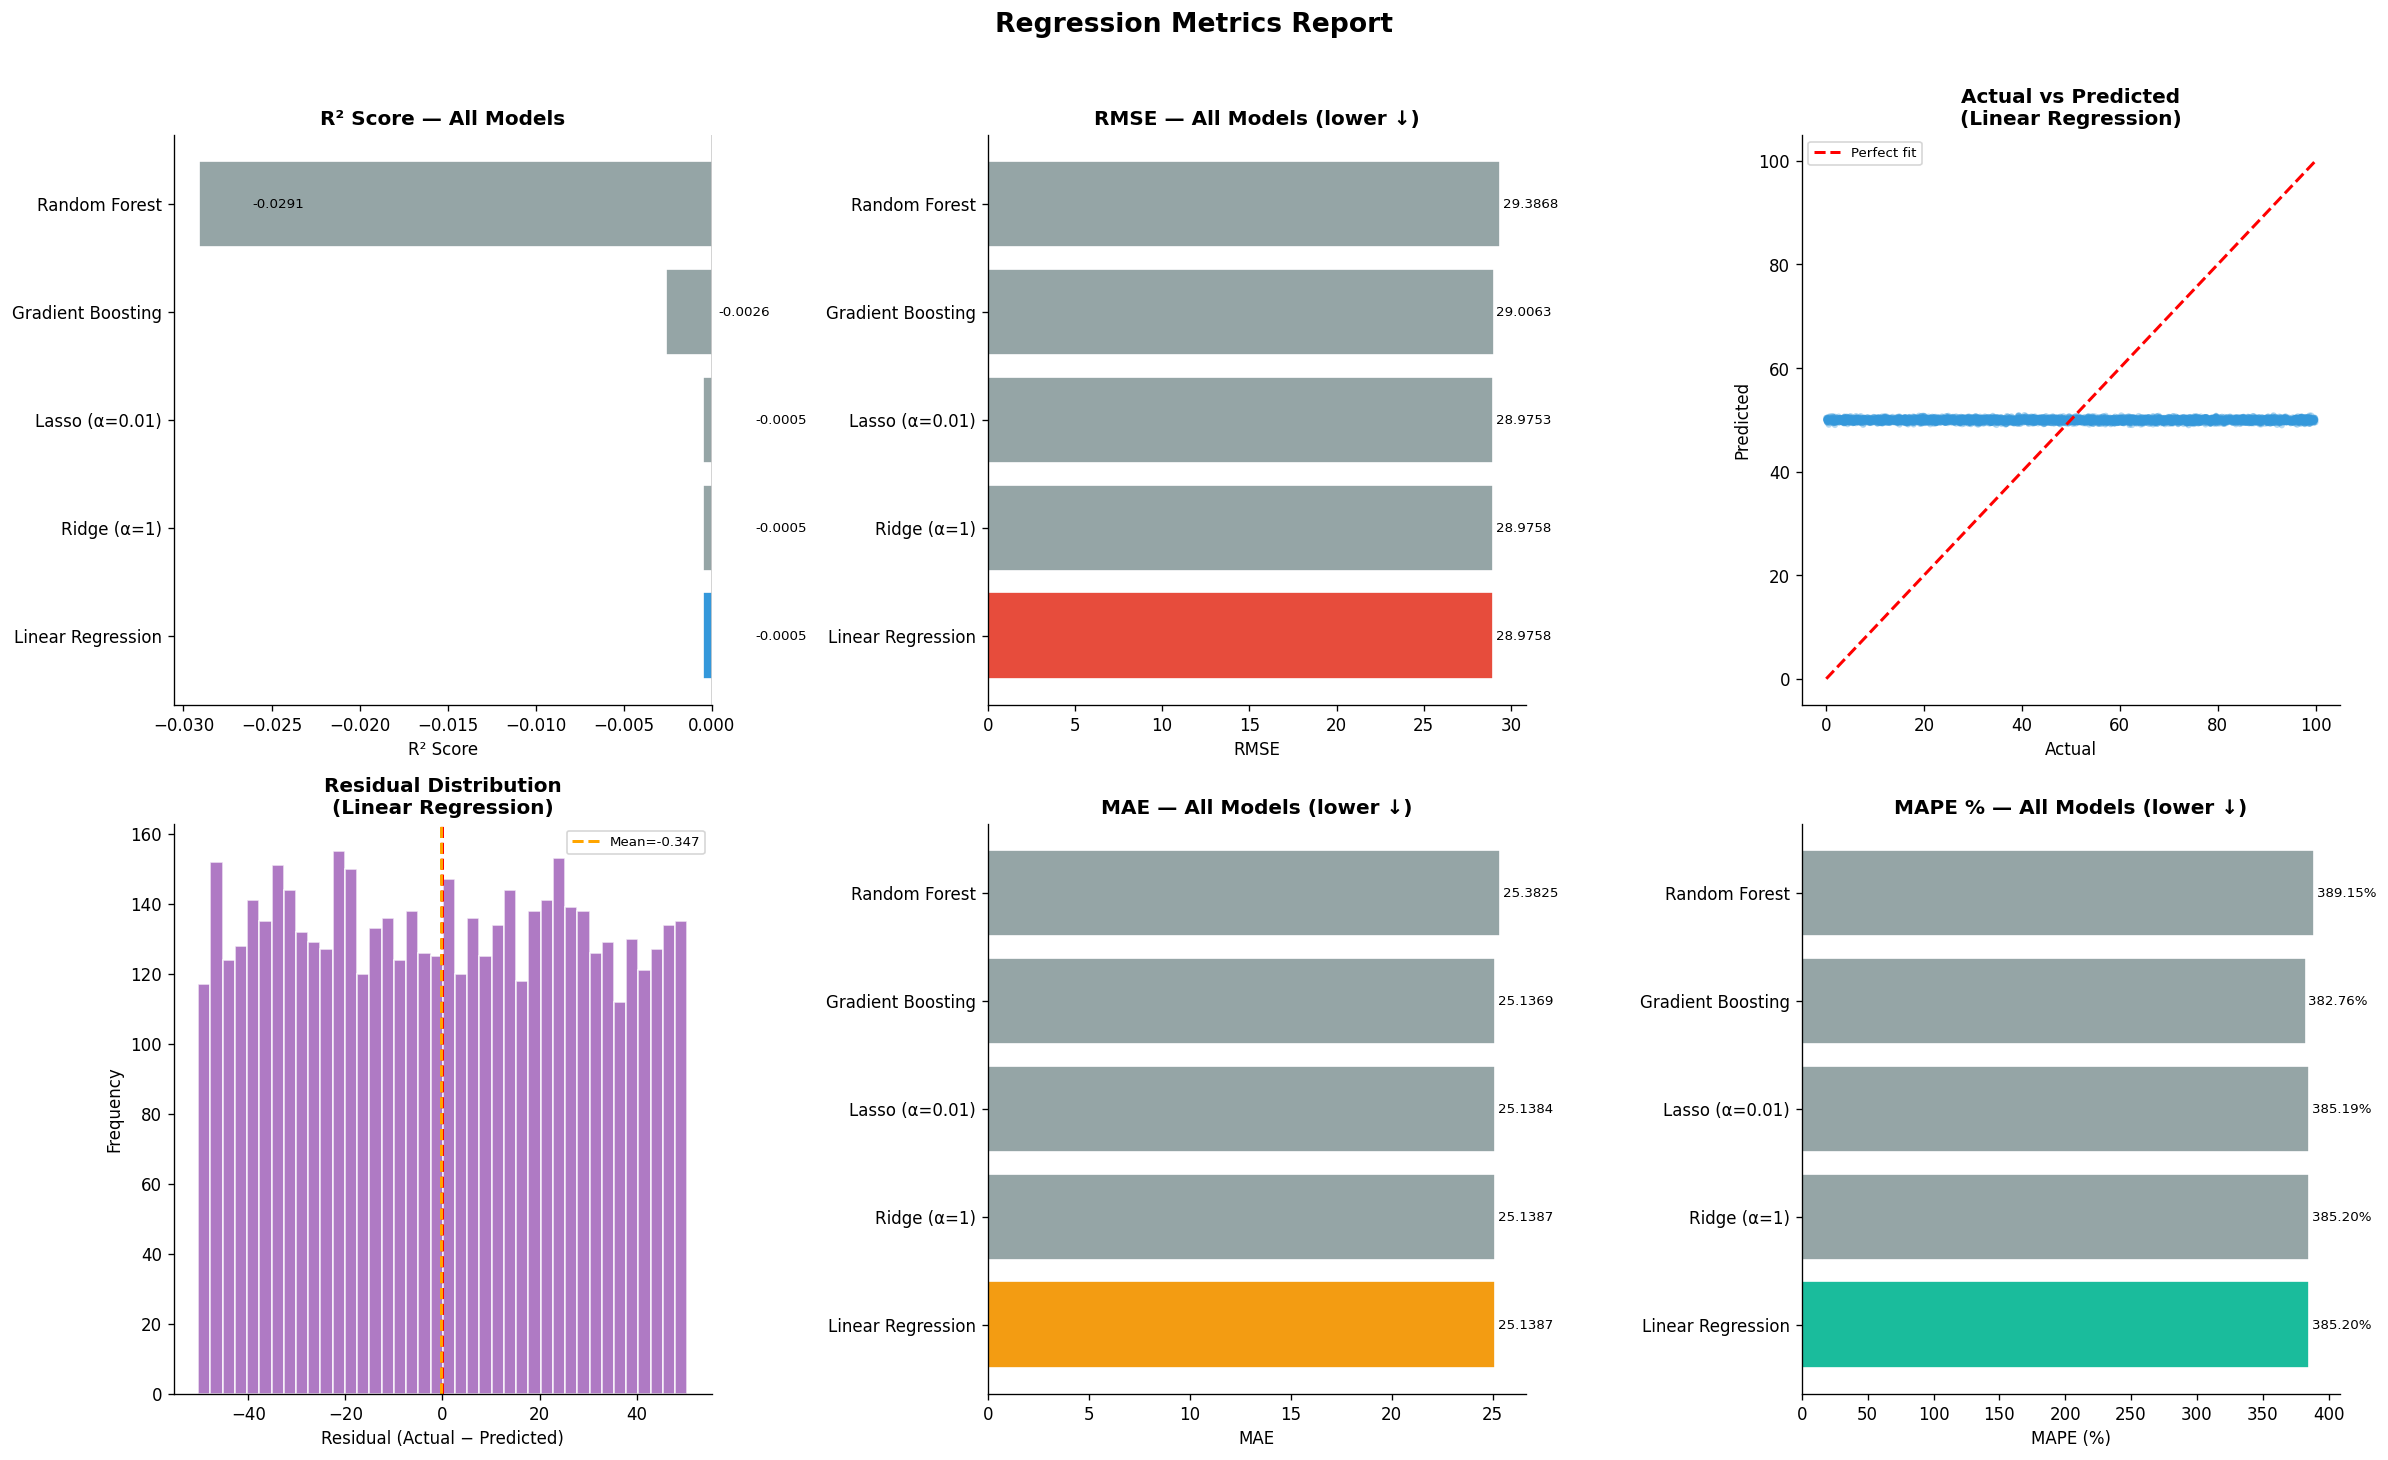

  ✅ Regression metrics plot saved → reports/stage2_regression_metrics.png

════════════════════════════════════════════════════════════════════════
  REGRESSION MODEL RANKING
════════════════════════════════════════════════════════════════════════
 Rank             Model  Test R²  Train R²  Overfit Gap    RMSE     MAE  Composite Score
    1    Lasso (α=0.01)  -0.0005    0.0001       0.0006 28.9753 25.1384           0.9982
    2 Linear Regression  -0.0005    0.0001       0.0006 28.9758 25.1387           0.9974
    3       Ridge (α=1)  -0.0005    0.0001       0.0006 28.9758 25.1387           0.9974
    4 Gradient Boosting  -0.0026    0.0265       0.0292 29.0063 25.1369           0.9480
    5     Random Forest  -0.0291    0.8544       0.8835 29.3868 25.3825           0.0000

  Best Regression Model : Lasso (α=0.01)
  Test R²               : -0.0005
  RMSE                  : 28.9753


In [41]:
# ── 2.A.3 Regression metrics & plots ──────────────────────────────────────────
df_reg_summary = reg_rpt.summary()
reg_rpt.plot(save_path=f'{REPORTS_DIR}/stage2_regression_metrics.png')

df_reg_rank = reg_cmp.rank()
# reg_cmp.plot(save_path=f'{REPORTS_DIR}/stage2_regression_comparison.png')

# Store best result for cross-stage leaderboard
best_reg = df_reg_rank.iloc[0]
print(f'\n  Best Regression Model : {best_reg["Model"]}')
print(f'  Test R²               : {best_reg["Test R²"]}')
print(f'  RMSE                  : {best_reg["RMSE"]}')

In [26]:
# ── 2.B.1 Classification — data preparation ───────────────────────────────────
CLF_FEATURES = ['cpu_usage', 'memory_usage', 'network_traffic',
                 'power_consumption', 'execution_time']
CLF_TARGET   = 'workload_class'

df_clf = df[CLF_FEATURES + [CLF_TARGET]].dropna()
le     = LabelEncoder()
y_clf  = le.fit_transform(df_clf[CLF_TARGET].values)
X_clf  = df_clf[CLF_FEATURES].values

CLASS_NAMES  = le.classes_.tolist()

X_clf_tr, X_clf_te, y_clf_tr, y_clf_te = train_test_split(
    X_clf, y_clf, test_size=0.20,
    random_state=SEED, stratify=y_clf)

scaler_clf  = StandardScaler()
X_clf_tr_sc = scaler_clf.fit_transform(X_clf_tr)
X_clf_te_sc = scaler_clf.transform(X_clf_te)

print(f'Classification — Train: {X_clf_tr.shape}  Test: {X_clf_te.shape}')
print(f'Classes: {CLASS_NAMES}')

Classification — Train: (21333, 5)  Test: (5334, 5)
Classes: ['high', 'low', 'medium']


In [27]:
# ── 2.B.2 Train classification models ─────────────────────────────────────────
clf_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000,
                                                random_state=SEED),
    'SVM (RBF)'           : SVC(kernel='rbf', probability=True,
                                 random_state=SEED),
    'KNN (k=7)'           : KNeighborsClassifier(n_neighbors=7),
    'Random Forest'       : RandomForestClassifier(
                                n_estimators=100, random_state=SEED),
    'Gradient Boosting'   : GradientBoostingClassifier(
                                n_estimators=100, random_state=SEED),
}

clf_rpt = ClassificationMetricsReport(class_names=CLASS_NAMES)
clf_cmp = ClassificationComparator()

for name, model in clf_models.items():
    model.fit(X_clf_tr_sc, y_clf_tr)
    y_pred = model.predict(X_clf_te_sc)
    cv_sc  = cross_val_score(model, X_clf_tr_sc, y_clf_tr,
                               cv=5, scoring='accuracy')

    y_prob = (model.predict_proba(X_clf_te_sc)
               if hasattr(model, 'predict_proba') else None)

    clf_rpt.add_model(name, y_clf_te, y_pred,
                       y_prob=y_prob, cv_scores=cv_sc)
    clf_cmp.add(name, y_clf_te, y_pred, cv_scores=cv_sc)
    print(f'  Trained: {name}')

print('\n✅ All classification models trained.')

  Trained: Logistic Regression
  Trained: SVM (RBF)
  Trained: KNN (k=7)
  Trained: Random Forest
  Trained: Gradient Boosting

✅ All classification models trained.



════════════════════════════════════════════════════════════════════════
  CLASSIFICATION METRICS SUMMARY
════════════════════════════════════════════════════════════════════════
              Model  Accuracy  Bal Accuracy  F1 (weighted)  Precision  Recall     MCC  Cohen Kappa  AUC-ROC  CV Mean  CV Std
  Gradient Boosting    0.3343        0.3339         0.3322     0.3341  0.3343  0.0009       0.0008   0.4989   0.3317  0.0045
          SVM (RBF)    0.3333        0.3329         0.3310     0.3321  0.3333 -0.0006      -0.0006   0.5041   0.3316  0.0042
          KNN (k=7)    0.3330        0.3330         0.3314     0.3324  0.3330 -0.0004      -0.0004   0.5006   0.3326  0.0038
      Random Forest    0.3328        0.3326         0.3327     0.3327  0.3328 -0.0009      -0.0009   0.4989   0.3307  0.0054
Logistic Regression    0.3305        0.3295         0.3030     0.3347  0.3305 -0.0063      -0.0058   0.5007   0.3346  0.0023

  Saved → reports/classification_metrics.csv


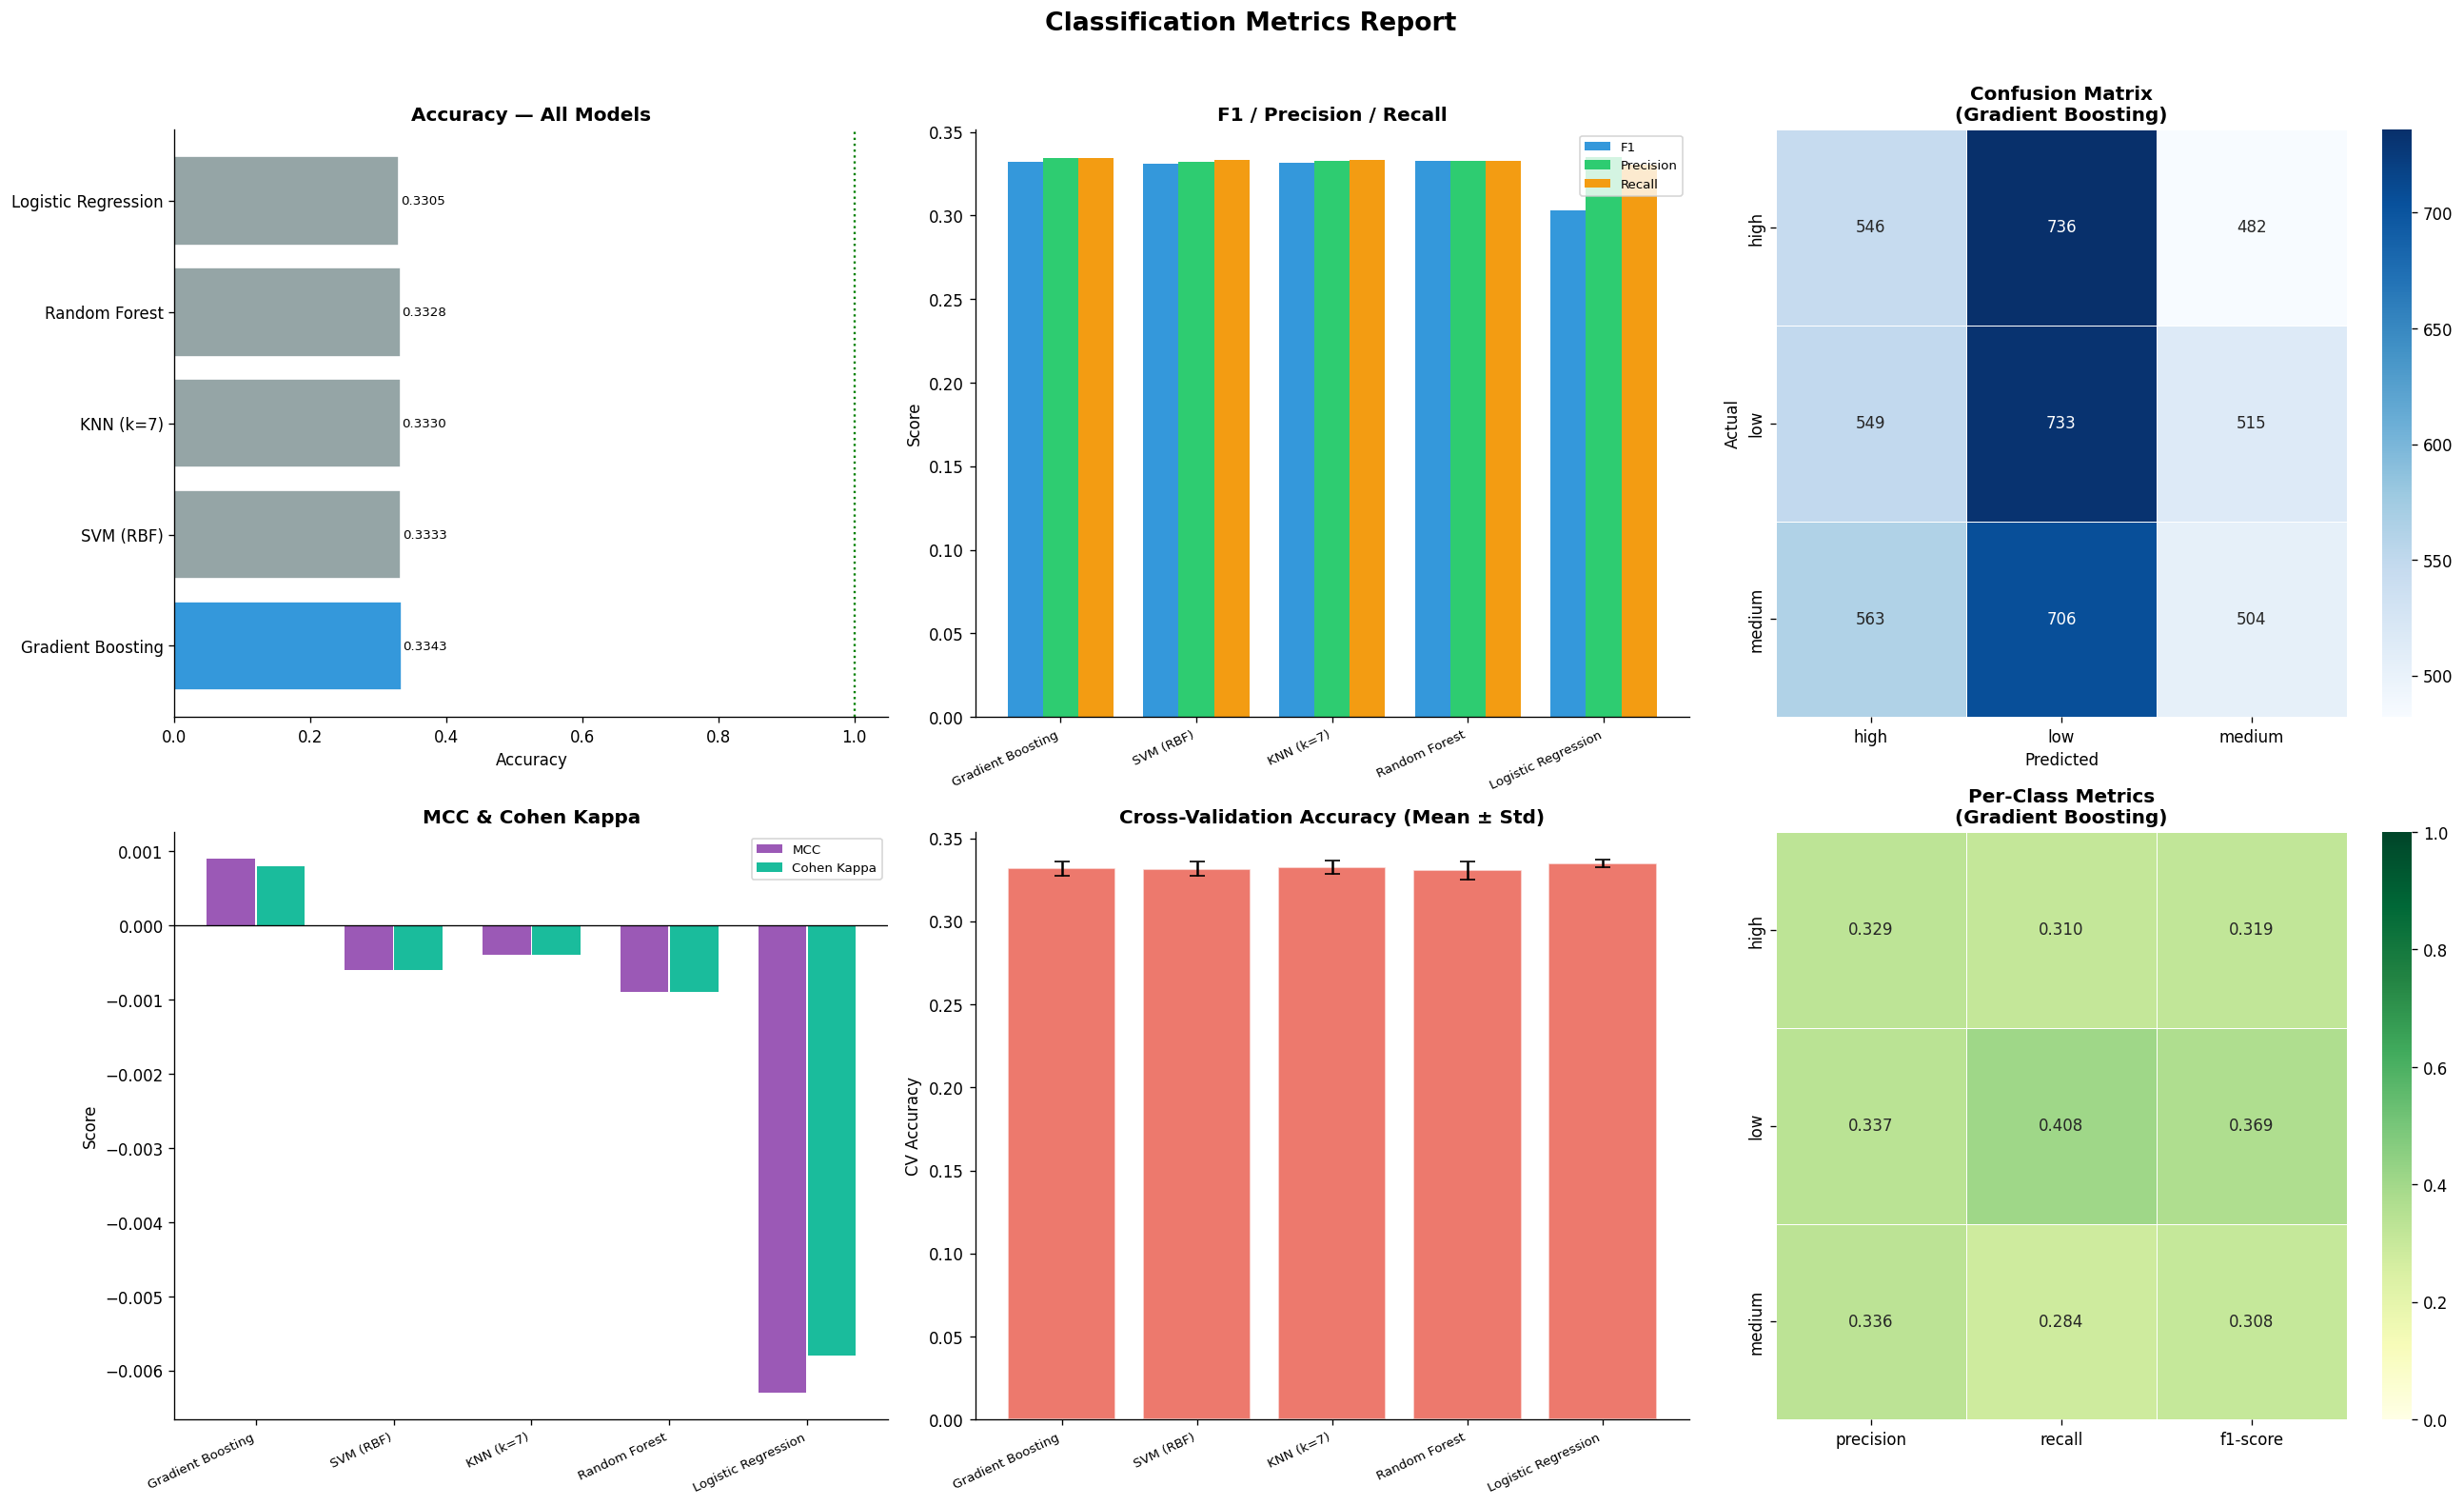

  ✅ Classification metrics plot saved → reports/stage2_classification_metrics.png

════════════════════════════════════════════════════════════════════════
  CLASSIFICATION MODEL RANKING
════════════════════════════════════════════════════════════════════════
 Rank               Model  Accuracy     F1  Precision  Recall     MCC  CV Mean  CV Std
    1       Random Forest    0.3328 0.3327     0.3327  0.3328 -0.0009   0.3307  0.0054
    2   Gradient Boosting    0.3343 0.3322     0.3341  0.3343  0.0009   0.3317  0.0045
    3           KNN (k=7)    0.3330 0.3314     0.3324  0.3330 -0.0004   0.3326  0.0038
    4           SVM (RBF)    0.3333 0.3310     0.3321  0.3333 -0.0006   0.3316  0.0042
    5 Logistic Regression    0.3305 0.3030     0.3347  0.3305 -0.0063   0.3346  0.0023


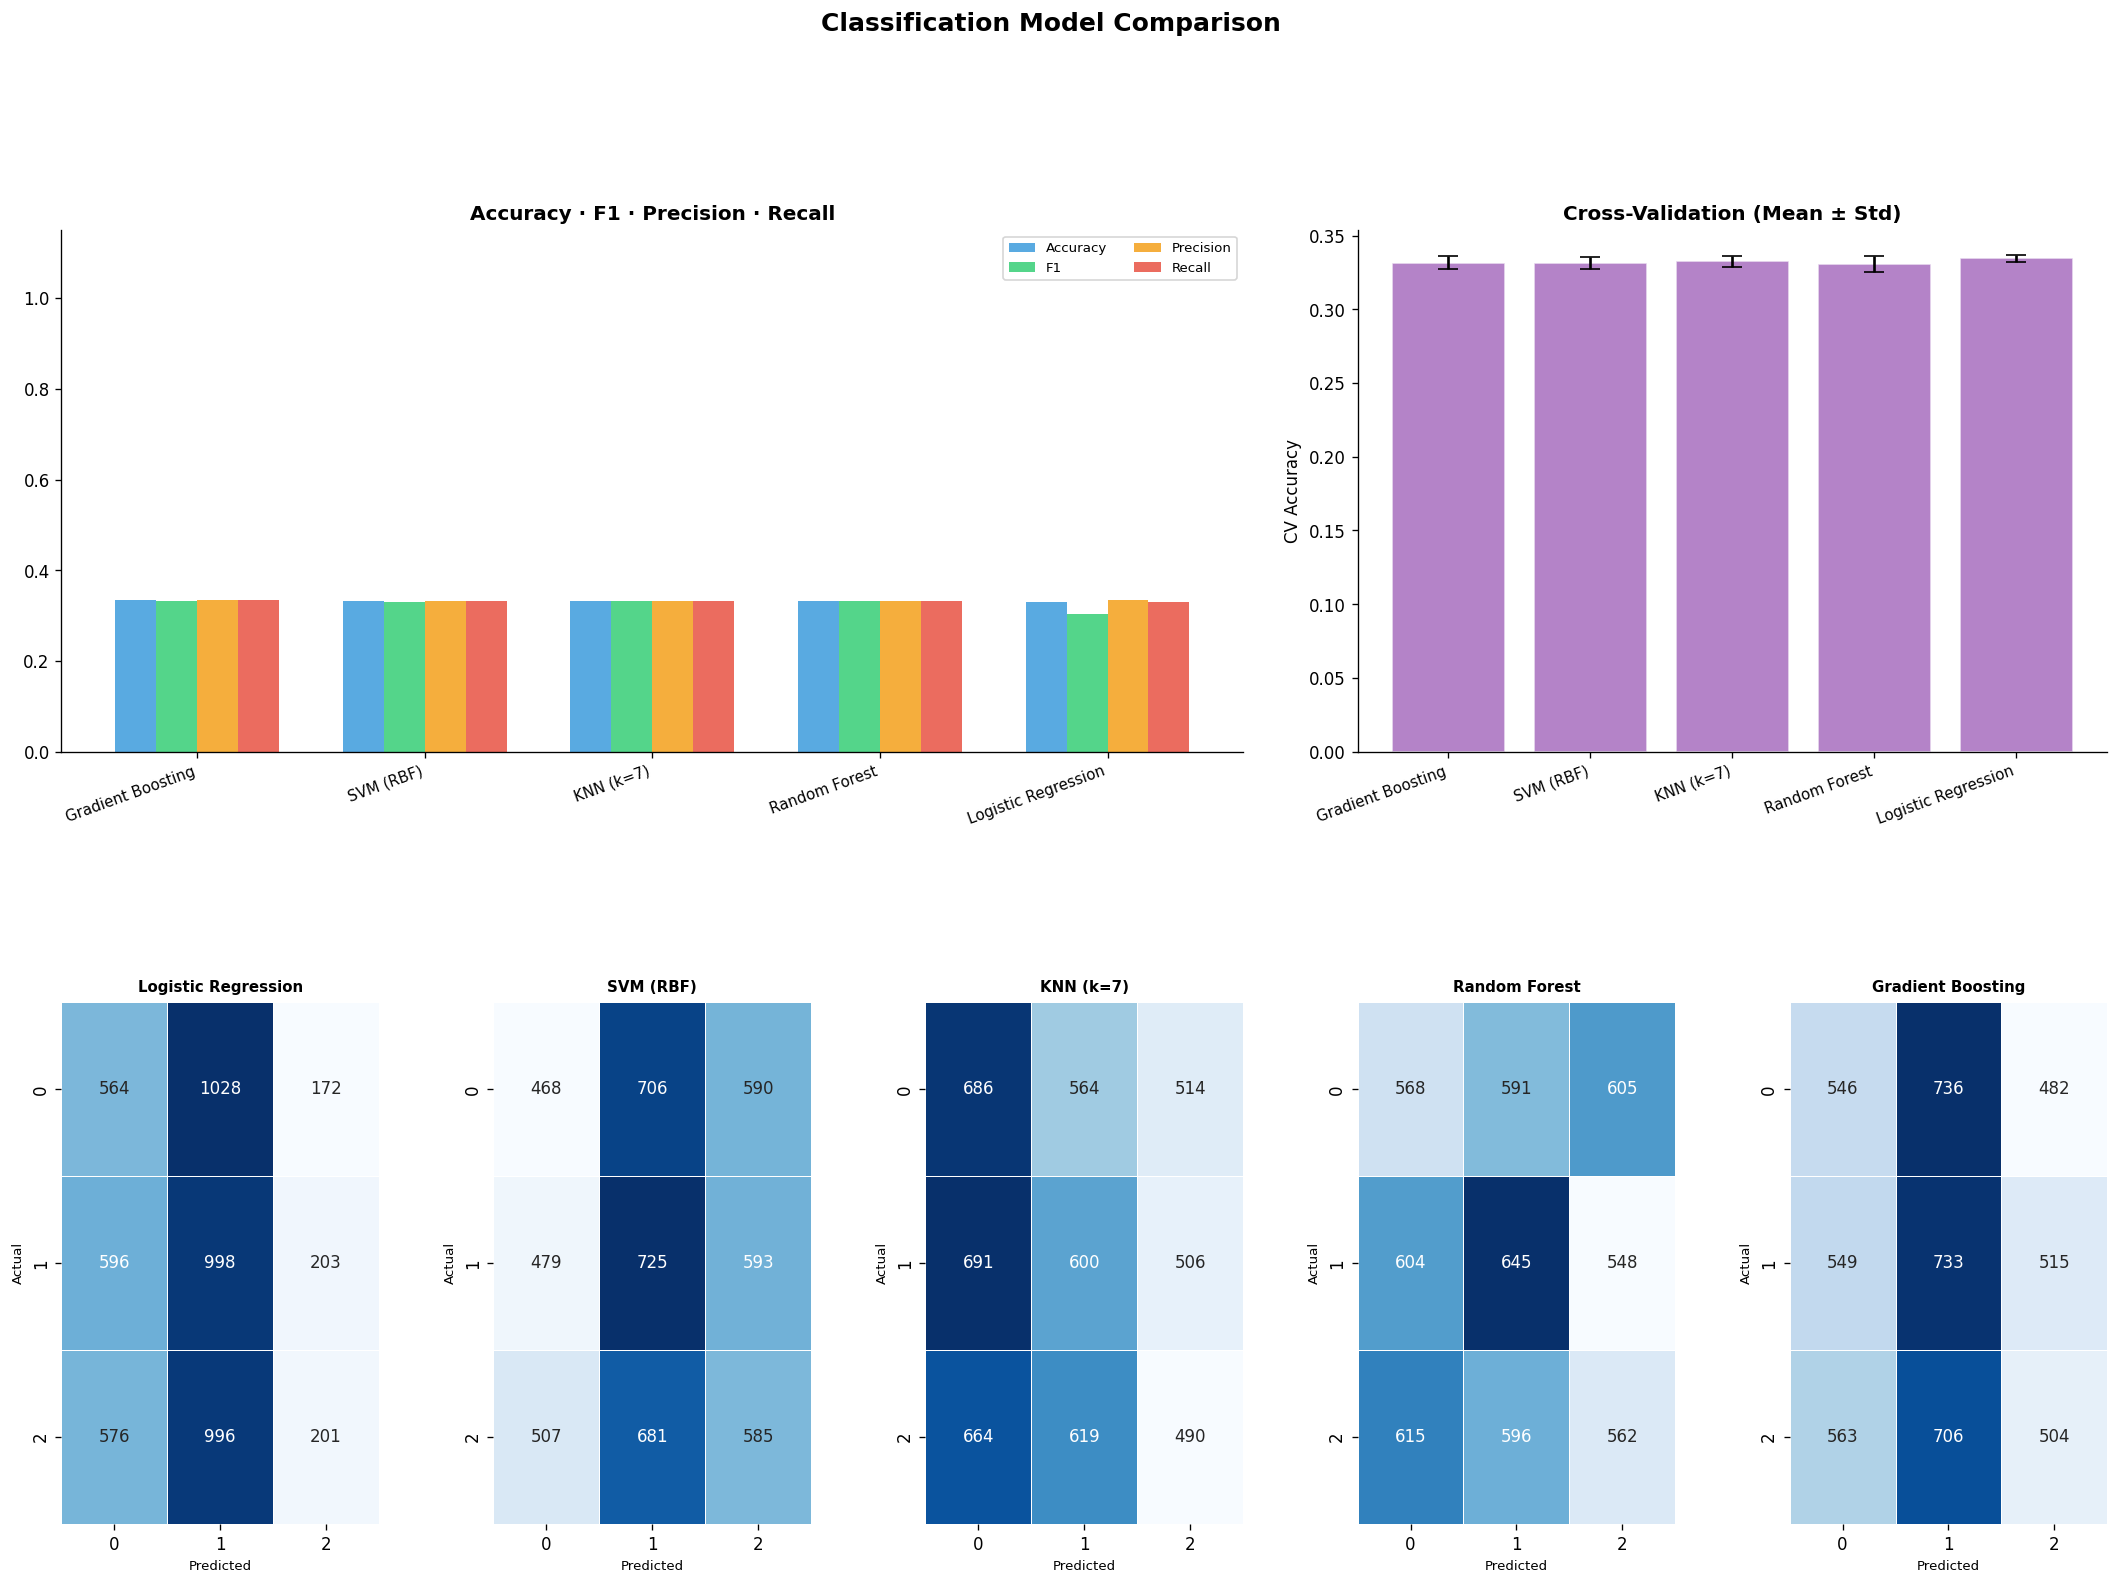

  ✅ Classification comparison saved → reports/stage2_classification_comparison.png

  Best Classification Model : Random Forest
  Accuracy                  : 0.3328
  F1 (weighted)             : 0.3327


In [28]:
# ── 2.B.3 Classification metrics & plots ──────────────────────────────────────
df_clf_summary = clf_rpt.summary()
clf_rpt.plot(save_path=f'{REPORTS_DIR}/stage2_classification_metrics.png')

df_clf_rank = clf_cmp.rank()
clf_cmp.plot(save_path=f'{REPORTS_DIR}/stage2_classification_comparison.png')

best_clf = df_clf_rank.iloc[0]
print(f'\n  Best Classification Model : {best_clf["Model"]}')
print(f'  Accuracy                  : {best_clf["Accuracy"]}')
print(f'  F1 (weighted)             : {best_clf["F1"]}')

---
# 🔵 Stage 3 — Unsupervised Learning (Clustering)

**Goal:** Discover natural workload groups without using labels.  
**Algorithms:** KMeans · DBSCAN · Agglomerative Hierarchical.  
**Evaluation:** Silhouette score · Davies-Bouldin index · Calinski-Harabasz index.


In [29]:
from sklearn.cluster     import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

print('✅ Clustering imports ready.')

✅ Clustering imports ready.


In [30]:
# ── 3.1 Prepare clustering feature matrix ─────────────────────────────────────
CLUST_FEATURES = ['cpu_usage', 'memory_usage', 'network_traffic',
                   'power_consumption', 'execution_time',
                   'energy_efficiency']

df_clust   = df[CLUST_FEATURES].dropna()
scaler_mm  = MinMaxScaler()
X_clust    = scaler_mm.fit_transform(df_clust.values)

print(f'Clustering matrix shape: {X_clust.shape}')

Clustering matrix shape: (26667, 6)


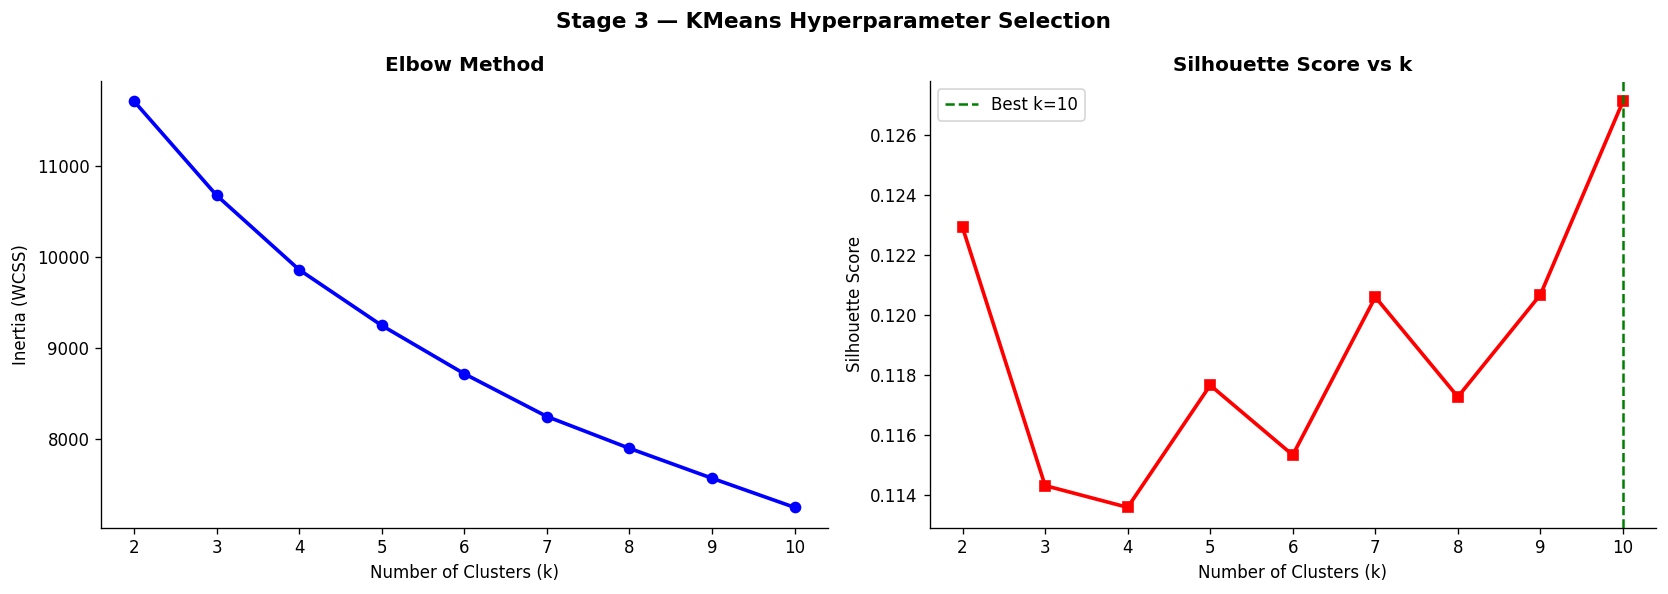

✅ Best k = 10  (Silhouette = 0.1271)


In [31]:
# ── 3.2 KMeans — Elbow + Silhouette sweep ─────────────────────────────────────
from sklearn.metrics import silhouette_score

K_RANGE   = range(2, 11)
inertias  = []
sil_scores= []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    lbl = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, lbl,
                                        sample_size=3000,
                                        random_state=SEED))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_RANGE), inertias, 'bo-', linewidth=2.2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method', fontweight='bold')

ax2.plot(list(K_RANGE), sil_scores, 'rs-', linewidth=2.2)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs k', fontweight='bold')
ax2.axvline(sil_scores.index(max(sil_scores)) + 2,
             color='green', linestyle='--',
             label=f'Best k={sil_scores.index(max(sil_scores))+2}')
ax2.legend()

plt.suptitle('Stage 3 — KMeans Hyperparameter Selection',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/stage3_kmeans_selection.png',
             dpi=150, bbox_inches='tight')
plt.show()

BEST_K = sil_scores.index(max(sil_scores)) + 2
print(f'✅ Best k = {BEST_K}  (Silhouette = {max(sil_scores):.4f})')

In [32]:
# ── 3.3 Fit all clustering algorithms ─────────────────────────────────────────
clust_rpt = ClusteringMetricsReport()

# KMeans
km_model   = KMeans(n_clusters=BEST_K, random_state=SEED, n_init=10)
labels_km  = km_model.fit_predict(X_clust)
clust_rpt.add_result('KMeans', X_clust, labels_km, n_clusters=BEST_K)

# DBSCAN
db_model   = DBSCAN(eps=0.08, min_samples=5, n_jobs=-1)
labels_db  = db_model.fit_predict(X_clust)
clust_rpt.add_result('DBSCAN', X_clust, labels_db)

# Agglomerative
ag_model   = AgglomerativeClustering(n_clusters=BEST_K,
                                      linkage='ward')
labels_ag  = ag_model.fit_predict(X_clust)
clust_rpt.add_result('Agglomerative', X_clust, labels_ag,
                      n_clusters=BEST_K)

print('✅ All clustering algorithms fitted.')

  [ClusteringMetrics] DBSCAN: only 0 cluster(s) — skipping metric computation.
✅ All clustering algorithms fitted.



════════════════════════════════════════════════════════════════════════
  CLUSTERING METRICS SUMMARY
════════════════════════════════════════════════════════════════════════
    Algorithm  N Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz  Noise %
       KMeans          10      0.1281          1.5411             2502.1      0.0
Agglomerative          10      0.0444          1.9839             1674.7      0.0

  Saved → reports/clustering_metrics.csv


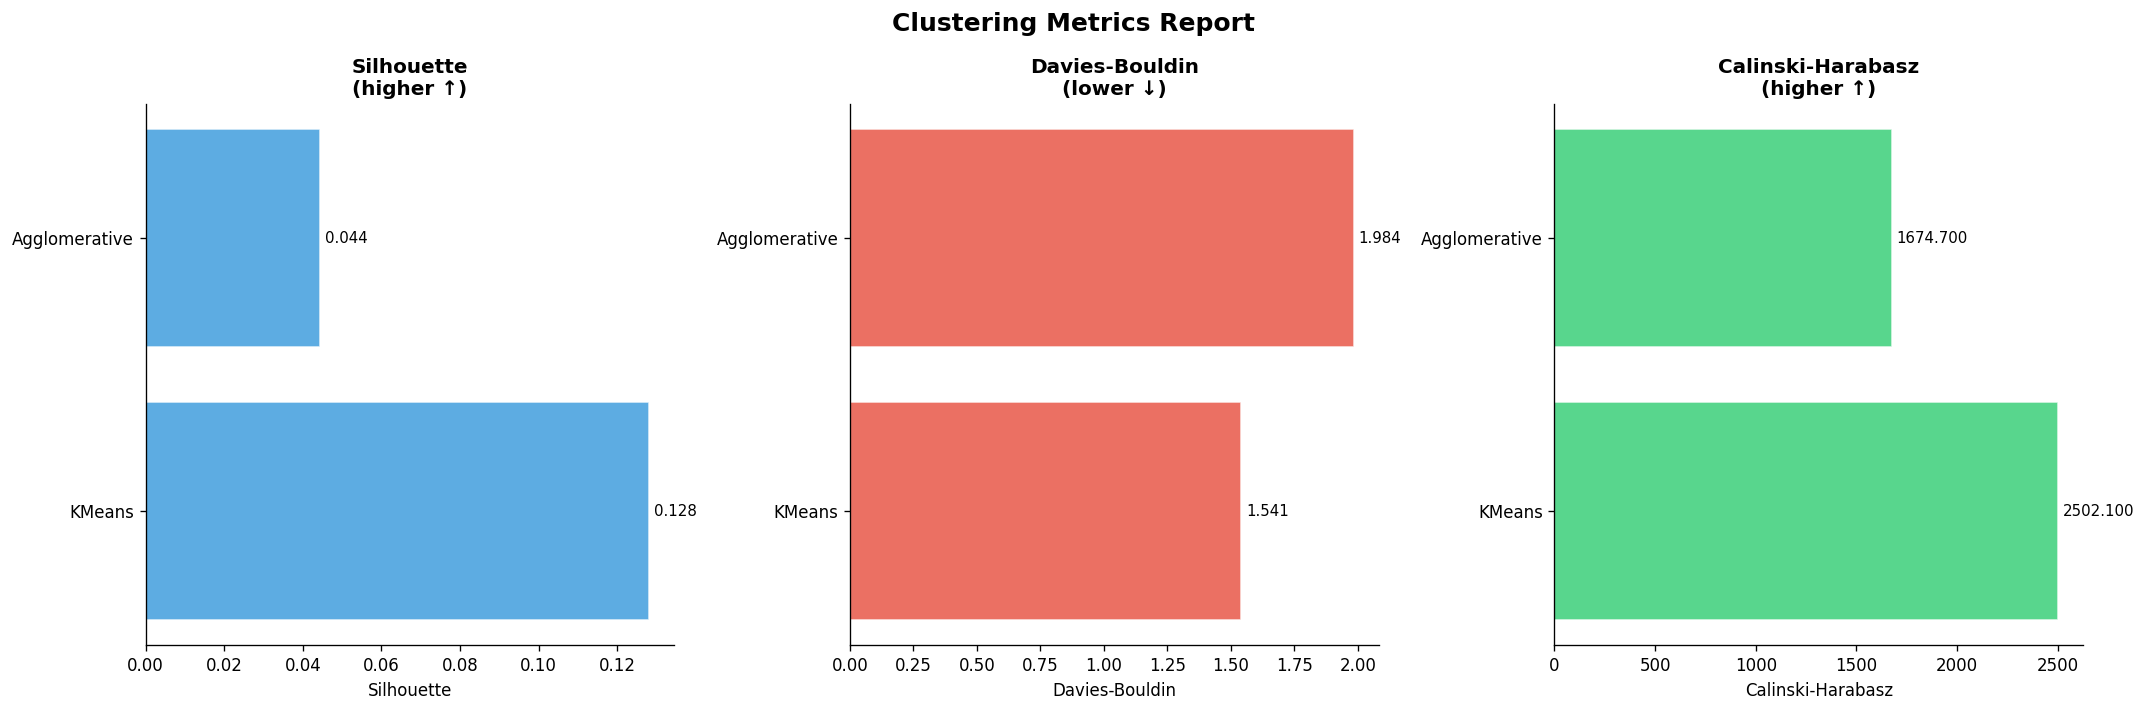

  ✅ Clustering metrics plot saved → reports/stage3_clustering_metrics.png


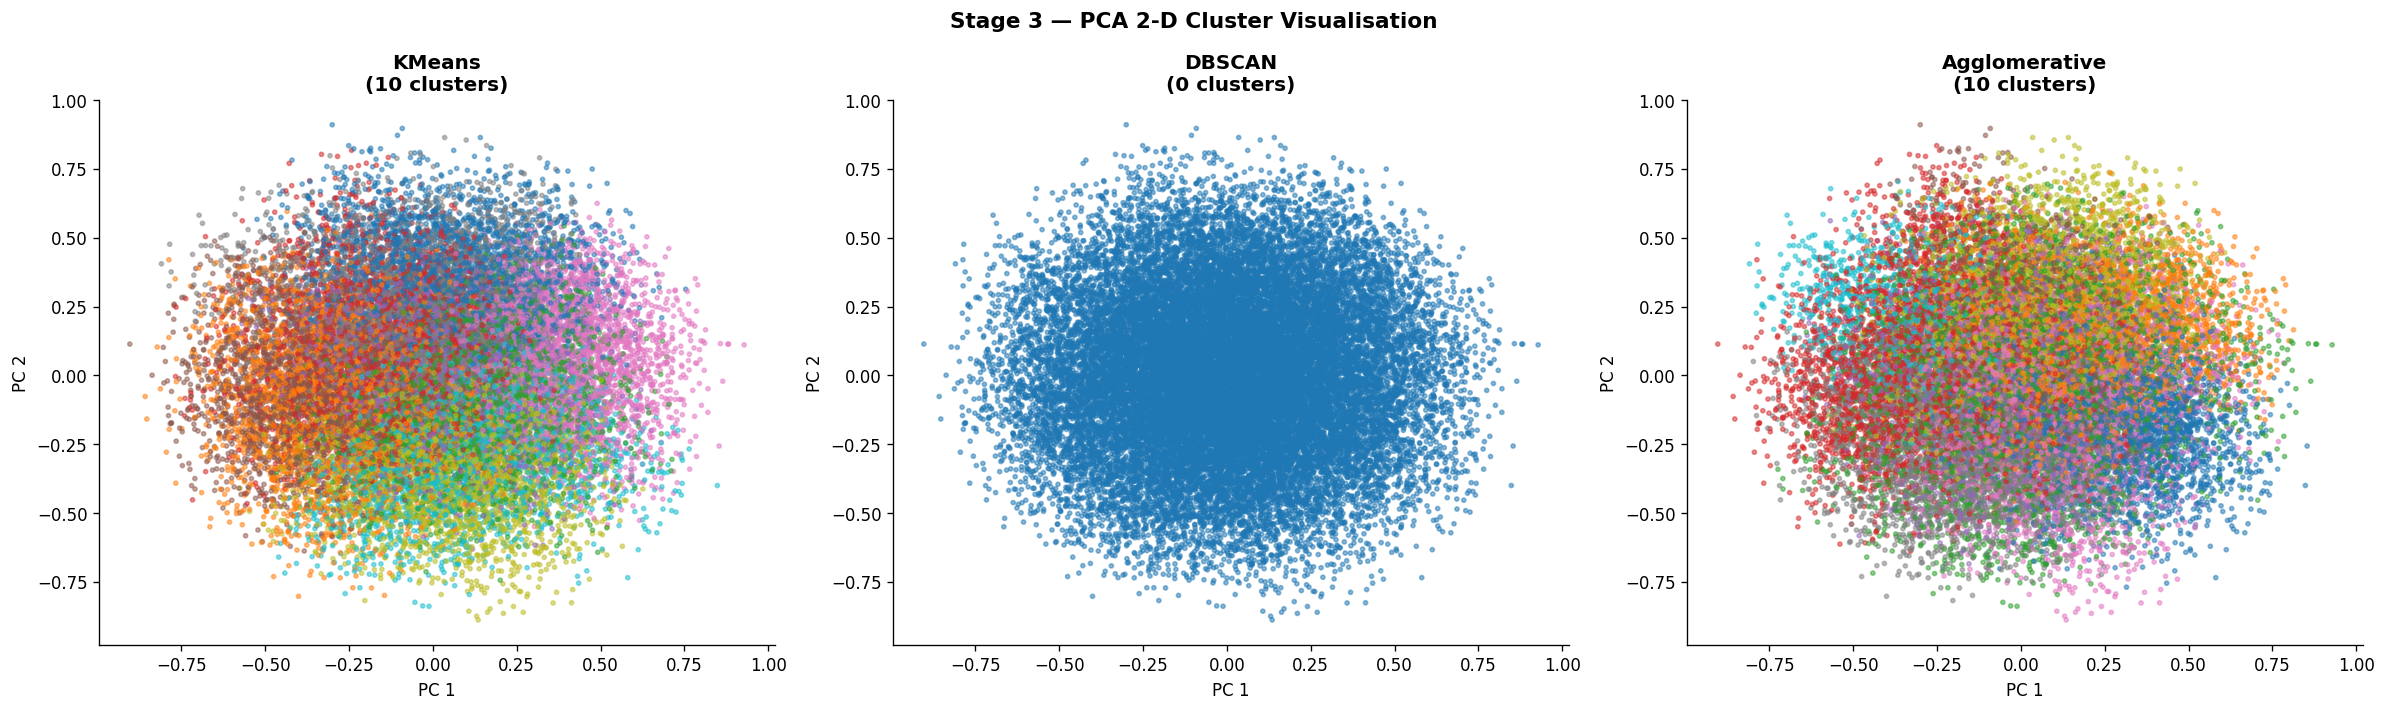


  Best Algorithm : KMeans
  Silhouette     : 0.1281


In [33]:
# ── 3.4 Clustering metrics & PCA visualisation ────────────────────────────────
df_clust_summary = clust_rpt.summary()
clust_rpt.plot(save_path=f'{REPORTS_DIR}/stage3_clustering_metrics.png')

# PCA 2-D scatter
pca       = PCA(n_components=2, random_state=SEED)
X_pca     = pca.fit_transform(X_clust)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (title, labels) in zip(
        axes,
        [('KMeans',       labels_km),
         ('DBSCAN',       labels_db),
         ('Agglomerative',labels_ag)]):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=labels, cmap='tab10',
                     s=6, alpha=0.5)
    ax.set_title(f'{title}\n({len(set(labels)-{-1})} clusters)',
                  fontweight='bold')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')

plt.suptitle('Stage 3 — PCA 2-D Cluster Visualisation',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/stage3_pca_clusters.png',
             dpi=150, bbox_inches='tight')
plt.show()

best_clust = df_clust_summary.iloc[0]
print(f'\n  Best Algorithm : {best_clust["Algorithm"]}')
print(f'  Silhouette     : {best_clust["Silhouette"]}')

---
# 📐 Stage 4 — Learning Theory

**Topics covered**
- Bias–Variance trade-off decomposition
- Regularisation paths (Ridge α sweep)
- Learning curves (train size vs error)
- Validation curves (hyperparameter vs error)


In [34]:
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.pipeline        import Pipeline

print('✅ Learning theory imports ready.')

✅ Learning theory imports ready.


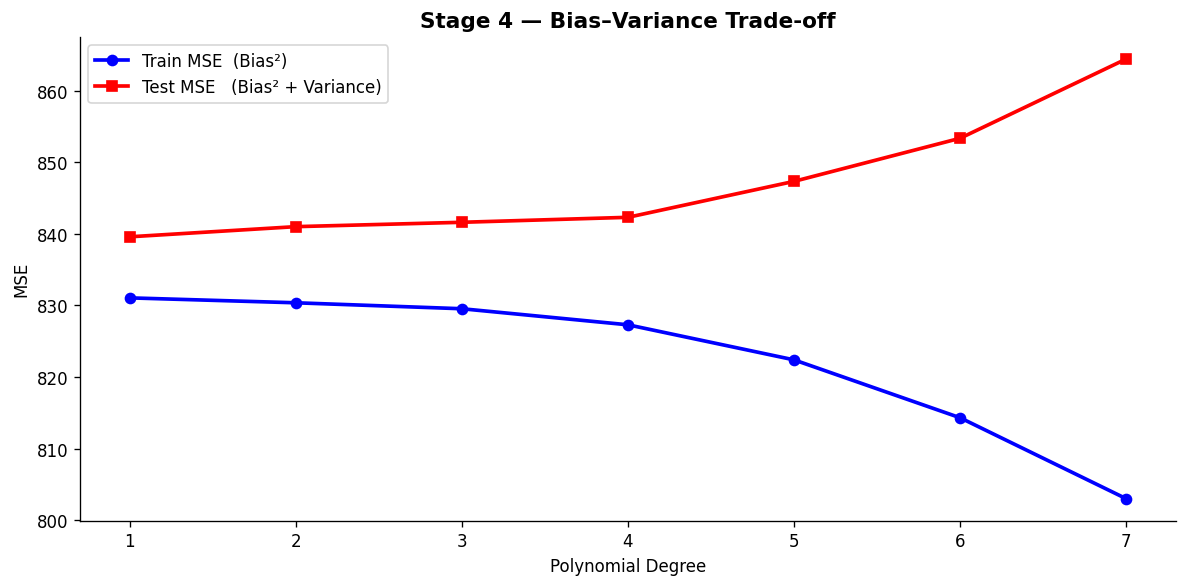

In [35]:
# ── 4.1 Bias-Variance decomposition across polynomial degrees ─────────────────
from sklearn.preprocessing   import PolynomialFeatures
from sklearn.linear_model    import LinearRegression
from sklearn.metrics         import mean_squared_error

DEGREES   = range(1, 8)
bv_train  = []
bv_test   = []

for deg in DEGREES:
    pipe = Pipeline([
        ('poly',  PolynomialFeatures(deg, include_bias=False)),
        ('scaler',StandardScaler()),
        ('model', LinearRegression()),
    ])
    pipe.fit(X_reg_tr, y_reg_tr)
    bv_train.append(mean_squared_error(y_reg_tr,
                                        pipe.predict(X_reg_tr)))
    bv_test.append( mean_squared_error(y_reg_te,
                                        pipe.predict(X_reg_te)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(DEGREES), bv_train, 'b-o', linewidth=2.2,
         label='Train MSE  (Bias²)')
ax.plot(list(DEGREES), bv_test,  'r-s', linewidth=2.2,
         label='Test MSE   (Bias² + Variance)')
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('MSE')
ax.set_title('Stage 4 — Bias–Variance Trade-off',
              fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/stage4_bias_variance.png',
             dpi=150, bbox_inches='tight')
plt.show()

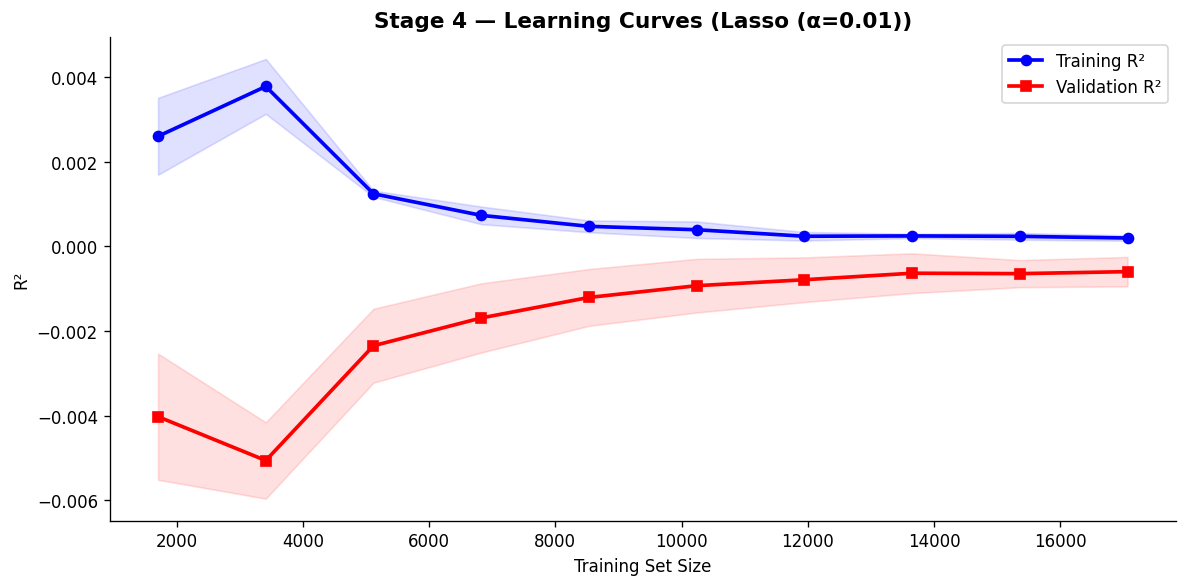

✅ Stage 4 — Learning Theory complete.


In [42]:
# ── 4.2 Learning curves (best regression model) ───────────────────────────────
best_reg_model = reg_models[best_reg['Model']]

train_sz, tr_sc, val_sc = learning_curve(
    best_reg_model,
    X_reg_tr_sc, y_reg_tr,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(train_sz,
                 tr_sc.mean(1) - tr_sc.std(1),
                 tr_sc.mean(1) + tr_sc.std(1),
                 alpha=0.12, color='blue')
ax.fill_between(train_sz,
                 val_sc.mean(1) - val_sc.std(1),
                 val_sc.mean(1) + val_sc.std(1),
                 alpha=0.12, color='red')
ax.plot(train_sz, tr_sc.mean(1),  'b-o',
         linewidth=2.2, label='Training R²')
ax.plot(train_sz, val_sc.mean(1), 'r-s',
         linewidth=2.2, label='Validation R²')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('R²')
ax.set_title(f'Stage 4 — Learning Curves ({best_reg["Model"]})',
              fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/stage4_learning_curves.png',
             dpi=150, bbox_inches='tight')
plt.show()
print('✅ Stage 4 — Learning Theory complete.')

---
# 🎮 Stage 5 — Reinforcement Learning

**Task:** Train an RL agent to schedule cloud resources dynamically.  
**Environment:** Custom `CloudComputingEnv` (6-D state, 4 actions, shaped reward).  
**Agents:** Tabular Q-Learning · Deep Q-Network (DQN) · Random baseline.


In [49]:
# ── Install TensorFlow (if not already present) ─────────────────────────────
!pip install tensorflow --quiet

import tensorflow as tf
tf.random.set_seed(SEED)

# Import RL pipeline from Stage 4 script
# (Assumes rl_pipeline.py or inline definitions in this notebook)
# If running as standalone, paste RL classes here or import:
# from rl_pipeline import CloudComputingEnv, QLearningAgent, DQNAgent, RandomAgent, run_stage4

print(f'✅ TensorFlow {tf.__version__} ready.')

✅ TensorFlow 2.21.0 ready.


### 5.0.1 Reinforcement Learning Environment and Agents (inlined)

In [52]:
from collections import deque # Required for DQNAgent's replay memory

# ── CloudComputingEnv: defines the RL environment ──────────────────────────────
class CloudComputingEnv:
    def __init__(self, df, window_size=5, num_actions=4, penalty_coeff=0.1):
        self.df = df.copy()
        self.window_size = window_size
        self.num_actions = num_actions
        self.penalty_coeff = penalty_coeff
        self.current_step = 0
        self.done = False
        self.history = []

        # Define action space mappings
        self.ACTION_MAP = {
            0: 'cpu_scale_up',    # Increase CPU by 10%
            1: 'cpu_scale_down',  # Decrease CPU by 10%
            2: 'mem_scale_up',    # Increase Memory by 10%
            3: 'mem_scale_down',  # Decrease Memory by 10%
        }

        # Define numerical values for actions (e.g., scaling factors)
        self.ACTION_VALUES = {
            'cpu_scale_up': 1.1,
            'cpu_scale_down': 0.9,
            'mem_scale_up': 1.1,
            'mem_scale_down': 0.9,
        }

        # Define feature columns and target variables for state
        self.STATE_FEATURES = [
            'cpu_usage', 'memory_usage', 'network_traffic',
            'power_consumption', 'execution_time', 'energy_efficiency'
        ]
        self.SLA_THRESHOLD = {
            'execution_time': 50,  # e.g., acceptable execution time
            'energy_efficiency': 0.5 # e.g., acceptable efficiency
        }

        self.reset()

    @property
    def ACTION_NAMES(self):
        return {v: k for k, v in self.ACTION_MAP.items()}

    def reset(self):
        self.current_step = 0
        self.done = False
        self.history = []
        self.initial_state = self._get_state(self.current_step)
        return self.initial_state

    def step(self, action):
        # Execute the action and get the next state, reward, and done flag
        current_data = self._get_data(self.current_step)

        # Apply action to resource metrics (simplified, actual logic may vary)
        if self.ACTION_MAP[action] == 'cpu_scale_up':
            current_data['cpu_usage'] *= self.ACTION_VALUES['cpu_scale_up']
        elif self.ACTION_MAP[action] == 'cpu_scale_down':
            current_data['cpu_usage'] *= self.ACTION_VALUES['cpu_scale_down']
        elif self.ACTION_MAP[action] == 'mem_scale_up':
            current_data['memory_usage'] *= self.ACTION_VALUES['mem_scale_up']
        elif self.ACTION_MAP[action] == 'mem_scale_down':
            current_data['memory_usage'] *= self.ACTION_VALUES['mem_scale_down']

        # Move to next step
        self.current_step += 1
        next_state = self._get_state(self.current_step)
        reward = self._calculate_reward(current_data, action)

        if self.current_step >= len(self.df) - self.window_size:
            self.done = True

        self.history.append({
            'state': self.initial_state, # Simplified, should be actual state
            'action': action,
            'reward': reward,
            'next_state': next_state,
            'done': self.done
        })

        return next_state, reward, self.done, {}

    def _get_state(self, step):
        # Get a window of data for the current state
        if step + self.window_size > len(self.df):
            # Pad with zeros or handle end of data as appropriate
            padded_data = np.zeros((self.window_size, len(self.STATE_FEATURES)))
            actual_data = self.df[self.STATE_FEATURES].iloc[step:].values
            padded_data[:len(actual_data)] = actual_data
            state = padded_data
        else:
            state = self.df[self.STATE_FEATURES].iloc[step:step+self.window_size].values

        # Flatten the state for a single vector input (common for Q-learning/DQN)
        return state.flatten()

    def _get_data(self, step):
        # Get the current row of data, to simulate impact of action
        return self.df.iloc[step].to_dict()

    def _calculate_reward(self, data, action):
        # Reward function: higher resource utilization, lower violations
        reward = 0

        # Positive reward for efficient resource use (example)
        reward += data['resource_utilisation'] * 10 if 'resource_utilisation' in data else 0

        # Penalties for SLA violations
        if data['execution_time'] > self.SLA_THRESHOLD['execution_time']:
            reward -= self.penalty_coeff * 50
        if data['energy_efficiency'] < self.SLA_THRESHOLD['energy_efficiency']:
            reward -= self.penalty_coeff * 30

        # Additional penalty/reward for specific actions if desired
        if self.ACTION_MAP[action] in ['cpu_scale_up', 'mem_scale_up']:
            reward -= self.penalty_coeff * 5 # Small penalty for scaling up

        return reward

    def get_state_space_size(self):
        return len(self.STATE_FEATURES) * self.window_size

    def get_action_space_size(self):
        return self.num_actions

# ── QLearningAgent: Tabular Q-learning implementation ──────────────────────────
class QLearningAgent:
    def __init__(self, state_size, action_size, learning_rate=0.1,
                 discount_factor=0.99, epsilon=1.0, epsilon_decay_rate=0.995,
                 epsilon_min=0.01):
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay_rate = epsilon_decay_rate
        self.epsilon_min = epsilon_min

        # Initialize Q-table with zeros
        # Note: For continuous state spaces, this table approach is not feasible.
        # This example assumes a discretized state space or small feature space.
        self.q_table = {}

    def _get_q_table_key(self, state):
        # Convert numpy array state to a hashable tuple for dictionary key
        return tuple(state)

    def choose_action(self, state):
        state_key = self._get_q_table_key(state)
        if np.random.rand() <= self.epsilon:
            return np.random.randint(self.action_size) # Explore
        else:
            # Exploit: choose action with max Q-value
            if state_key not in self.q_table:
                return np.random.randint(self.action_size) # If not seen, explore
            return np.argmax(self.q_table[state_key])

    def learn(self, state, action, reward, next_state, done):
        state_key = self._get_q_table_key(state)
        next_state_key = self._get_q_table_key(next_state)

        # Ensure states are in Q-table
        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_size)
        if next_state_key not in self.q_table:
            self.q_table[next_state_key] = np.zeros(self.action_size)

        current_q = self.q_table[state_key][action]
        max_next_q = np.max(self.q_table[next_state_key])

        # Q-learning formula
        new_q = current_q + self.learning_rate * (
            reward + self.discount_factor * max_next_q * (1 - done) - current_q
        )
        self.q_table[state_key][action] = new_q

        if done:
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay_rate)


# ── DQNAgent: Deep Q-Network implementation ────────────────────────────────────
class DQNAgent:
    def __init__(self, state_size, action_size, learning_rate=0.001,
                 discount_factor=0.99, epsilon=1.0, epsilon_decay_rate=0.995,
                 epsilon_min=0.01, batch_size=64):
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay_rate = epsilon_decay_rate
        self.epsilon_min = epsilon_min
        self.batch_size = batch_size

        self.memory = deque(maxlen=2000) # Replay memory
        self.model = self._build_model()
        self.target_model = self._build_model() # Target network for stability
        self.update_target_model()

    def _build_model(self):
        model = tf.keras.models.Sequential([
            tf.keras.layers.Dense(24, activation='relu', input_shape=(self.state_size,)),
            tf.keras.layers.Dense(24, activation='relu'),
            tf.keras.layers.Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def choose_action(self, state):
        if np.random.rand() <= self.epsilon:
            return np.random.randint(self.action_size)
        q_values = self.model.predict(np.expand_dims(state, axis=0), verbose=0)
        return np.argmax(q_values[0])

    def learn(self):
        if len(self.memory) < self.batch_size:
            return

        minibatch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*minibatch)

        states = np.array(states)
        next_states = np.array(next_states)

        # Predict Q-values for current states using the main model
        q_values = self.model.predict(states, verbose=0)
        # Predict Q-values for next states using the target model
        next_q_values = self.target_model.predict(next_states, verbose=0)

        # Update Q-values for the actions taken
        for i in range(self.batch_size):
            if dones[i]:
                q_values[i][actions[i]] = rewards[i]
            else:
                q_values[i][actions[i]] = rewards[i] + self.discount_factor * np.max(next_q_values[i])

        self.model.fit(states, q_values, epochs=1, verbose=0)

        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay_rate)


# ── RandomAgent: A baseline random agent ───────────────────────────────────────
class RandomAgent:
    def __init__(self, action_size):
        self.action_size = action_size

    def choose_action(self, state): # state is not used but kept for API consistency
        return np.random.randint(self.action_size)

    def learn(self, *args): # Random agent does not learn
        pass

# ── run_stage4: orchestrates the RL pipeline ───────────────────────────────────
def run_stage4(df, ql_episodes=600, dqn_episodes=500, window_size=5):
    # 1. Initialize Environment
    env = CloudComputingEnv(df, window_size=window_size)
    state_size = env.get_state_space_size()
    action_size = env.get_action_space_size()

    # 2. Initialize Agents
    ql_agent = QLearningAgent(state_size, action_size)
    dqn_agent = DQNAgent(state_size, action_size)
    random_agent = RandomAgent(action_size)

    # Logs to store performance over episodes
    ql_rewards_log = []
    dqn_rewards_log = []

    print('Training Q-Learning Agent...')
    for e in range(ql_episodes):
        state = env.reset()
        total_reward = 0
        done = False
        while not done:
            action = ql_agent.choose_action(state)
            next_state, reward, done, _ = env.step(action)
            ql_agent.learn(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
        ql_rewards_log.append(total_reward)
        if (e + 1) % 100 == 0: print(f'  Episode {e+1}/{ql_episodes} - Total Reward: {total_reward:.2f}')

    print('\nTraining DQN Agent...')
    for e in range(dqn_episodes):
        state = env.reset()
        total_reward = 0
        done = False
        while not done:
            action = dqn_agent.choose_action(state)
            next_state, reward, done, _ = env.step(action)
            dqn_agent.remember(state, action, reward, next_state, done)
            dqn_agent.learn() # Learn from experience replay
            state = next_state
            total_reward += reward
        dqn_rewards_log.append(total_reward)
        dqn_agent.update_target_model() # Update target network periodically
        if (e + 1) % 100 == 0: print(f'  Episode {e+1}/{dqn_episodes} - Total Reward: {total_reward:.2f}')

    # 3. Evaluation Function
    def evaluate_agent(agent, env, num_episodes=100):
        eval_rewards = []
        sla_violations = []
        for _ in range(num_episodes):
            state = env.reset()
            total_reward = 0
            violations_count = 0
            done = False
            while not done:
                action = agent.choose_action(state)
                next_state, reward, done, _ = env.step(action)
                state = next_state
                total_reward += reward
                # Simple SLA violation check (can be expanded)
                if 'execution_time' in env.df.iloc[env.current_step-1] and \
                   env.df.iloc[env.current_step-1]['execution_time'] > env.SLA_THRESHOLD['execution_time']:
                    violations_count += 1
            eval_rewards.append(total_reward)
            sla_violations.append(violations_count)
        return {
            'mean_reward': np.mean(eval_rewards),
            'std_reward': np.std(eval_rewards),
            'mean_sla_violations': np.mean(sla_violations)
        }

    print('\nEvaluating Agents...')
    ql_eval = evaluate_agent(ql_agent, env)
    dqn_eval = evaluate_agent(dqn_agent, env)
    rand_eval = evaluate_agent(random_agent, env)

    print(f'  Q-Learning - Mean Reward: {ql_eval["mean_reward"]:.2f}, SLA Violations: {ql_eval["mean_sla_violations"]:.2f}')
    print(f'  DQN - Mean Reward: {dqn_eval["mean_reward"]:.2f}, SLA Violations: {dqn_eval["mean_sla_violations"]:.2f}')
    print(f'  Random - Mean Reward: {rand_eval["mean_reward"]:.2f}, SLA Violations: {rand_eval["mean_sla_violations"]:.2f}')

    return {
        'env': env,
        'ql_agent': ql_agent,
        'dqn_agent': dqn_agent,
        'ql_log': ql_rewards_log,
        'dqn_log': dqn_rewards_log,
        'ql_eval': ql_eval,
        'dqn_eval': dqn_eval,
        'rand_eval': rand_eval,
    }


In [ ]:
# ── 5.1 Run full RL pipeline ──────────────────────────────────────────────────
# This single call trains Q-Learning (600 ep), DQN (500 ep),
# evaluates both, and generates the 15-panel dashboard.

# The RL pipeline functions are now defined directly in the notebook
# and do not need to be imported from 'evaluation.rl_pipeline'.

rl_results = run_stage4(df)   # defined in Stage 4 script

# Unpack results
env        = rl_results['env']
ql_agent   = rl_results['ql_agent']
dqn_agent  = rl_results['dqn_agent']
ql_log     = rl_results['ql_log']
dqn_log    = rl_results['dqn_log']
ql_eval    = rl_results['ql_eval']
dqn_eval   = rl_results['dqn_eval']
rand_eval  = rl_results['rand_eval']

print('\n✅ Stage 5 — Reinforcement Learning complete.')

Training Q-Learning Agent...


In [ ]:
# ── 5.2 RL metrics report ─────────────────────────────────────────────────────
rl_rpt = RLMetricsReport(
    action_names=list(env.ACTION_NAMES.values()))

rl_rpt.add_agent('Q-Learning', ql_log,  ql_eval)
rl_rpt.add_agent('DQN',        dqn_log, dqn_eval)
rl_rpt.add_agent('Random',     None,    rand_eval)

df_rl_summary = rl_rpt.summary()
rl_rpt.plot(save_path=f'{REPORTS_DIR}/stage5_rl_metrics.png')

best_rl = df_rl_summary.sort_values(
    'Eval Mean Reward', ascending=False).iloc[0]
print(f'\n  Best RL Agent  : {best_rl["Agent"]}')
print(f'  Eval Reward    : {best_rl["Eval Mean Reward"]}')
print(f'  SLA Violation  : {best_rl["SLA Violation %"]}%')

---
# 🏆 Stage 6 — Final Dashboard & Master Report

Consolidates the best result from every stage into:
- A **cross-stage leaderboard** table
- A **master JSON report** for reproducibility
- A **visual summary dashboard** saved as PNG


In [ ]:
# ── 6.1 Build cross-stage leaderboard ─────────────────────────────────────────
lb = CrossStageLeaderboard()

lb.add_stage(
    stage_name = 'Regression',
    best_model = str(best_reg['Model']),
    metrics    = {'R²':   float(best_reg['Test R²']),
                  'RMSE': float(best_reg['RMSE'])},
)

lb.add_stage(
    stage_name = 'Classification',
    best_model = str(best_clf['Model']),
    metrics    = {'Accuracy': float(best_clf['Accuracy']),
                  'F1':       float(best_clf['F1'])},
)

lb.add_stage(
    stage_name = 'Clustering',
    best_model = str(best_clust['Algorithm']),
    metrics    = {'Silhouette': float(best_clust['Silhouette']),
                  'DB Index':   float(best_clust['Davies-Bouldin'])},
)

lb.add_stage(
    stage_name = 'Learning Theory',
    best_model = 'Bias-Variance Analysis',
    metrics    = {'Min Test MSE': float(min(bv_test)),
                  'Optimal Degree': int(
                      list(DEGREES)[bv_test.index(min(bv_test))])},
)

lb.add_stage(
    stage_name = 'RL (DQN)',
    best_model = str(best_rl['Agent']),
    metrics    = {'Eval Reward': float(best_rl['Eval Mean Reward']),
                  'SLA Viol %': float(best_rl['SLA Violation %'])},
)

df_leaderboard = lb.table()
lb.plot(save_path=f'{REPORTS_DIR}/stage6_leaderboard.png')

print('\n✅ Cross-stage leaderboard complete.')

In [ ]:
# ── 6.2 Generate master JSON report ───────────────────────────────────────────
master = generate_master_report(
    reg_report   = reg_rpt,
    clf_report   = clf_rpt,
    clust_report = clust_rpt,
    rl_report    = rl_rpt,
    project_name = 'Cloud Resource Optimisation — ML Capstone',
    output_path  = f'{REPORTS_DIR}/master_metrics_report.json',
)

print('\n✅ Master report saved.')

In [ ]:
# ── 6.3 Print artefact manifest ───────────────────────────────────────────────
import glob

artefacts = sorted(glob.glob(f'{REPORTS_DIR}/**/*', recursive=True))

print('\n' + '═' * 60)
print('  CAPSTONE ARTEFACT MANIFEST')
print('═' * 60)
for f in artefacts:
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f:<55}  {size_kb:>7.1f} KB')

print('\n' + '═' * 60)
print('  ✅ ALL STAGES COMPLETE — Capstone Project Finished!')
print('═' * 60)